<div style="
    background: linear-gradient(135deg, #0f172a, #1e293b);
    padding: 3%;
    margin: 2% auto;
    width: 95%;
    max-width: 1500px;
    min-width: 280px;
    border-radius: 18px;
    color: #e2e8f0;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 8px 25px rgba(0,0,0,0.35);
    box-sizing: border-box;
">

<h1 style="
    text-align:center;
    color:#38bdf8;
    margin-bottom:25px;
">
🛒 Customer Segmentation & Smart Product Recommendation
</h1>

<p style="font-size:17px; line-height:1.8; margin-bottom:20px; color:#cbd5f5;">
This project explores the dynamic landscape of <b style="color:#22c55e;">online retail analytics</b> by studying a detailed transactional dataset from a UK-based retailer.  
The dataset, obtained from the <b style="color:#fbbf24;">UCI Machine Learning Repository</b>, records every purchase made between <b>2010 and 2011</b>, providing a rich foundation for customer behavior analysis.
</p>

<p style="font-size:17px; line-height:1.8; margin-bottom:20px; color:#cbd5f5;">
Our central goal is to <b style="color:#f472b6;">improve marketing effectiveness</b> and <b style="color:#4ade80;">increase sales performance</b> through advanced customer segmentation techniques.  
To accomplish this, raw transaction data is reshaped into a <b>customer-focused dataset</b> by engineering meaningful features that reveal purchasing trends and habits.
</p>

<p style="font-size:17px; line-height:1.8; margin-bottom:25px; color:#cbd5f5;">
We then apply the <b style="color:#60a5fa;">K-Means clustering algorithm</b> to group customers into distinct segments based on similarities in their shopping patterns.  
This process enables us to uncover unique <b>customer profiles</b>, preferences, and behavioral insights across different groups.
</p>

<div style="
    background:#020617;
    padding:18px;
    margin-top:10px;
    border-left:6px solid #38bdf8;
    border-radius:10px;
    box-sizing:border-box;
    width:100%;
">
<b style="color:#7dd3fc;">Key Objectives:</b>

<ul style="
    margin:8px 0 0 0;
    padding-left:20px;
    line-height:1.8;
    color:#c7d2fe;
">

<li><b style="color:#22c55e;">Data Cleaning & Transformation:</b> Refine the dataset by addressing missing entries, removing duplicates, and treating outliers.</li>

<li><b style="color:#fbbf24;">Feature Engineering:</b> Construct meaningful attributes to reshape data into a customer-centric structure.</li>

<li><b style="color:#a78bfa;">Data Preprocessing:</b> Normalize and reduce dimensionality to improve clustering performance.</li>

<li><b style="color:#60a5fa;">Customer Segmentation (K-Means):</b> Group customers based on behavioral similarities.</li>

<li><b style="color:#f472b6;">Cluster Analysis & Evaluation:</b> Profile each cluster and validate segmentation quality.</li>

<li><b style="color:#facc15;">Recommendation System:</b> Suggest popular products to customers who haven’t purchased them yet.</li>

</ul>
</div>

</div>


<div style="
background: linear-gradient(135deg, #020617, #0f172a);
padding: 3%;
margin: 2% auto;
border-radius: 16px;
color: #e5e7eb;
font-family: 'Segoe UI', Arial, sans-serif;
box-shadow: 0 6px 18px rgba(0,0,0,0.35);
box-sizing: border-box;
max-width: 1500px;
width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Importing Necessary Libraries
</h2>

</div>


In [68]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#import data
import os
import kagglehub

# Data manipulation & stats
import pandas as pd
import numpy as np
from collections import Counter
from scipy.stats import linregress

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors as mcolors
import matplotlib.cm as cm

# Machine learning & clustering
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Misc
from tabulate import tabulate

%matplotlib inline


In [69]:
# Configure Seaborn plot styles: Set background color and use dark grid
sns.set(rc={'axes.facecolor': '#fcf0dc'}, style='darkgrid')

<div style="
background: linear-gradient(135deg, #020617, #0f172a);
padding: 3%;
margin: 2% auto;
border-radius: 16px;
color: #e5e7eb;
font-family: 'Segoe UI', Arial, sans-serif;
box-shadow: 0 6px 18px rgba(0,0,0,0.35);
box-sizing: border-box;
max-width: 1500px;
width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Loading the Dataset
</h2>

</div>


In [70]:
# Download latest version
path = kagglehub.dataset_download("carrie1/ecommerce-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\carrie1\ecommerce-data\versions\1


In [71]:
#Load data to DataFrame
df = pd.read_csv(os.path.join(path, "data.csv"), encoding='cp1252')

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Dataset Description:
</h2>

<table style="
    width: 100%;
    border-collapse: collapse;
    color: #c7d2fe;
">
    <thead>
        <tr>
            <th style="border-bottom: 2px solid #38bdf8; padding: 10px; text-align:left;">Variable</th>
            <th style="border-bottom: 2px solid #38bdf8; padding: 10px; text-align:left;">Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">InvoiceNo</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Code representing each unique transaction. If this code starts with the letter 'c', it indicates a cancellation.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">StockCode</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Code uniquely assigned to each distinct product.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Description</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Description of each product.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Quantity</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The number of units of a product in a transaction.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">InvoiceDate</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The date and time of the transaction.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">UnitPrice</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The unit price of the product in sterling.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">CustomerID</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Identifier uniquely assigned to each customer.</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Country</td>
            <td style="padding: 8px;">The country of the customer.</td>
        </tr>
    </tbody>
</table>

</div>


<div style="
background: linear-gradient(135deg, #020617, #0f172a);
padding: 3%;
margin: 2% auto;
border-radius: 16px;
color: #e5e7eb;
font-family: 'Segoe UI', Arial, sans-serif;
box-shadow: 0 6px 18px rgba(0,0,0,0.35);
box-sizing: border-box;
max-width: 1500px;
width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Initial Data Analysis
</h2>



<div style="
background: linear-gradient(135deg, #020617, #0f172a);
padding: 3%;
margin: 2% auto;
border-radius: 16px;
color: #e5e7eb;
font-family: 'Segoe UI', Arial, sans-serif;
box-shadow: 0 6px 18px rgba(0,0,0,0.35);
box-sizing: border-box;
max-width: 1500px;
width: 95%;
">



<h3 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Dataset Overview
</h3>
<p> First, I will perform an initial analysis to examine the structure and types of the dataset’s columns</p>

</div>

In [72]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inferences:
</h2>

<p style="color:#c7d2fe; line-height:1.8;">
The dataset consists of <strong>541,909 entries</strong> and <strong>8 columns</strong>. Here is a brief overview of each column:
</p>

<ul style="color:#c7d2fe; line-height:1.8; padding-left: 20px;">
    <li><strong>InvoiceNo:</strong> Object type column containing the invoice number for each transaction. Each invoice can include multiple items.</li>
    <li><strong>StockCode:</strong> Object type column representing the product code for each item.</li>
    <li><strong>Description:</strong> Object type column with product descriptions. It has some missing values (540,455 non-null entries out of 541,909).</li>
    <li><strong>Quantity:</strong> Integer column indicating the number of products purchased in each transaction.</li>
    <li><strong>InvoiceDate:</strong> Datetime column recording the date and time of each transaction.</li>
    <li><strong>UnitPrice:</strong> Float column representing the unit price of each product.</li>
    <li><strong>CustomerID:</strong> Float column containing customer IDs. It has many missing values (406,829 non-null entries out of 541,909).</li>
    <li><strong>Country:</strong> Object column recording the country of each transaction.</li>
</ul>

<p style="color:#c7d2fe; line-height:1.8;">
From this preliminary overview, we observe missing values in the <strong>Description</strong> and <strong>CustomerID</strong> columns, which will need to be addressed. The <strong>InvoiceDate</strong> column is already in datetime format, facilitating future time series analysis. Additionally, a single customer may have multiple transactions, as indicated by repeated CustomerIDs.
</p>

<p style="color:#c7d2fe; line-height:1.8;">
Next steps include deeper data cleaning and preprocessing to handle missing values and potentially erroneous data, as well as creating new features to support the project objectives.
</p>

</div>


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">
<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Summary Statistics
</h2>

In [74]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [75]:
# Summary statistics for categorical variables
df.describe(include='object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/2011 14:41,1114
Country,541909,38,United Kingdom,495478


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inferences:
</h2>

<h3 style="color:#7dd3fc; margin-top:15px;">Quantity</h3>
<ul style="color:#c7d2fe; line-height:1.8; padding-left: 20px;">
    <li>The average quantity of products per transaction is approximately <strong>9.55</strong>.</li>
    <li>Quantity ranges widely, from <strong>-80995</strong> to <strong>80995</strong>. Negative values indicate returned or cancelled orders that need proper handling.</li>
    <li>The large standard deviation suggests a significant spread in the data. Outliers are present, as shown by the large difference between the maximum and the 75th percentile values.</li>
</ul>

<h3 style="color:#7dd3fc; margin-top:15px;">UnitPrice</h3>
<ul style="color:#c7d2fe; line-height:1.8; padding-left: 20px;">
    <li>The average unit price of products is approximately <strong>4.61</strong>.</li>
    <li>Unit prices range from <strong>-11062.06</strong> to <strong>38970</strong>, indicating possible errors or noise since negative prices are invalid.</li>
    <li>Outliers are present, as seen in the large difference between the maximum and the 75th percentile values.</li>
</ul>

<h3 style="color:#7dd3fc; margin-top:15px;">CustomerID</h3>
<ul style="color:#c7d2fe; line-height:1.8; padding-left: 20px;">
    <li>There are <strong>406,829</strong> non-null entries, indicating missing values that need to be addressed.</li>
    <li>Customer IDs range from <strong>12346</strong> to <strong>18287</strong>, useful for identifying unique customers.</li>
</ul>

<h3 style="color:#7dd3fc; margin-top:15px;">InvoiceNo</h3>
<ul style="color:#c7d2fe; line-height:1.8; padding-left: 20px;">
    <li>There are <strong>25,900</strong> unique invoice numbers, representing separate transactions.</li>
    <li>The most frequent invoice number is <strong>573585</strong>, appearing 1,114 times, possibly representing a large transaction or an order with multiple items.</li>
</ul>

<h3 style="color:#7dd3fc; margin-top:15px;">StockCode</h3>
<ul style="color:#c7d2fe; line-height:1.8; padding-left: 20px;">
    <li>There are <strong>4,070</strong> unique stock codes representing different products.</li>
    <li>The most frequent stock code is <strong>85123A</strong>, appearing 2,313 times.</li>
</ul>

<h3 style="color:#7dd3fc; margin-top:15px;">Description</h3>
<ul style="color:#c7d2fe; line-height:1.8; padding-left: 20px;">
    <li>There are <strong>4,223</strong> unique product descriptions.</li>
    <li>The most frequent description is <strong>"WHITE HANGING HEART T-LIGHT HOLDER"</strong>, appearing 2,369 times.</li>
    <li>Some missing values exist in this column and need to be treated.</li>
</ul>

<h3 style="color:#7dd3fc; margin-top:15px;">Country</h3>
<ul style="color:#c7d2fe; line-height:1.8; padding-left: 20px;">
    <li>Transactions come from <strong>38</strong> countries.</li>
    <li>Approximately <strong>91.4%</strong> of transactions originate from the <strong>United Kingdom</strong>.</li>
</ul>

</div>


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Data Cleaning & Transformation
</h2>
<p>
This step involves a thorough data cleaning and transformation process, including handling missing values, removing duplicates, correcting anomalies in product codes and descriptions, and making other necessary adjustments to prepare the dataset for detailed analysis and modeling.
</p>


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Handling Missing Values
</h2>


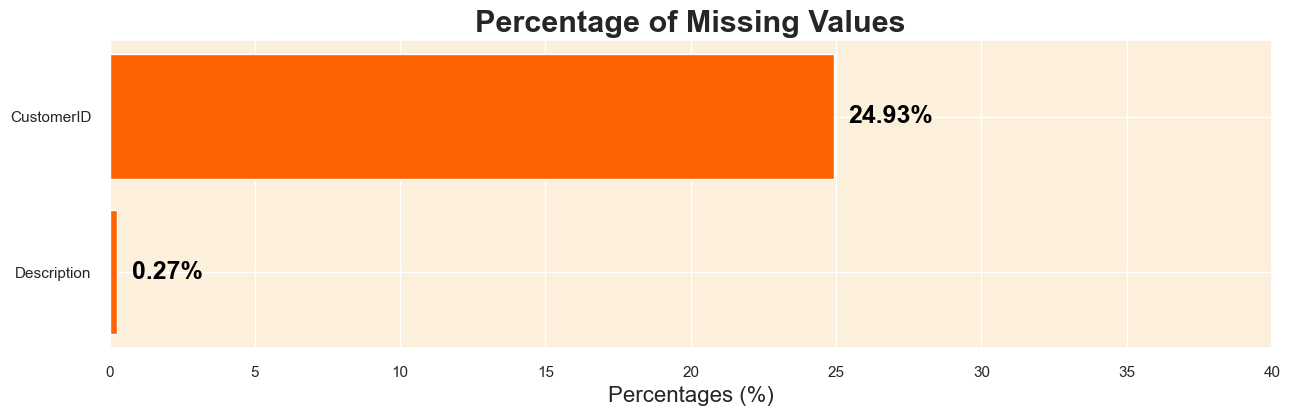

In [76]:
# Calculating the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)

# Plot the barh chart
fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color='#ff6200')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Handling Missing Values
</h2>
<p>
Handling Missing Values Strategy

CustomerID (24.93% missing values)
The CustomerID column has nearly a quarter of its values missing. This column is critical for clustering customers and building a recommendation system. Imputing such a large portion of missing data could introduce significant bias or noise.

Since clustering relies on accurate customer identifiers to reflect behavior and preferences, the most reliable approach is to remove rows with missing CustomerIDs. This ensures the integrity of clusters and downstream analyses.

Description (0.27% missing values)
The Description column has a very small proportion of missing values. However, inconsistencies exist where the same StockCode may have different descriptions, indicating data quality issues.

Imputing missing descriptions based on StockCode may not be reliable. Given the low percentage of missing values, removing these rows is a safer approach to prevent introducing errors into further analysis.

Conclusion
By removing rows with missing CustomerID and Description values, we create a cleaner, more reliable dataset, which is essential for accurate customer clustering and the development of an effective recommendation system.
</p>

In [77]:
# Extracting rows with missing values in 'CustomerID' or 'Description' columns
df[df["CustomerID"].isnull() | df["Description"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


In [78]:
# Removing rows with missing values in 'CustomerID' and 'Description' columns
df = df.dropna(subset=["CustomerID", "Description"])
# Verifying the removal of missing values
df.isnull().sum().sum()

np.int64(0)

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Handling Duplicates
</h2>


In [79]:
# Finding duplicate rows (keeping all instances)
duplicate_row = df[df.duplicated(keep=False)]
# Sorting the data by certain columns to see the duplicate rows next to each other
duplicate_rows_sorted = duplicate_row.sort_values(by=['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Quantity'])
# Displaying the first 10 records
duplicate_rows_sorted.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Handling Duplicates
</h2>
<p>Handling Duplicates Strategy

Within this project, the occurrence of fully identical rows — including the same transaction timestamps — is more likely to represent data entry or recording errors rather than legitimate repeated purchases. Retaining these duplicates could introduce noise and distort patterns used for clustering and recommendations.

For this reason, all completely identical duplicate records will be removed from the dataset. Eliminating these rows contributes to a cleaner and more reliable dataset, which supports more accurate customer clustering based on genuine purchasing behavior. It also improves the precision of the recommendation system by ensuring that product purchase frequencies are not artificially inflated by duplicated entries.</p>

In [80]:
# Displaying the number of duplicate rows
print(f"The dataset contains {df.duplicated().sum()} duplicate rows that need to be removed.")

# Removing duplicate rows
df.drop_duplicates(inplace=True)

The dataset contains 5225 duplicate rows that need to be removed.


In [81]:
# Getting the number of rows in the dataframe
df.shape[0]

401604

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Treating Cancelled Transactions
</h2>
<p>To refine our understanding of customer behavior and preferences, we need to take into account the transactions that were cancelled. Initially, we will identify these transactions by filtering the rows where the InvoiceNo starts with "C". Subsequently, we will analyze these rows to understand their common characteristics or patterns:</p>

In [82]:
# Filter out the rows with InvoiceNo starting with "C" and create a new column indicating the transaction status
df['Transaction_Status'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')

# Analyze the characteristics of these rows (considering the new column)
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
cancelled_transactions.describe().drop('CustomerID', axis=1)

,Quantity,UnitPrice
count,8872.000000,8872.000000
mean,-30.774910,18.899512
std,1172.249902,445.190864
min,-80995.000000,0.010000
25%,-6.000000,1.450000
50%,-2.000000,2.950000
75%,-1.000000,4.950000
max,-1.000000,38970.000000


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Treating Cancelled Transactions
</h2>

<p>Inferences from the Cancelled Transactions Data:
All quantities in the cancelled transactions are negative, indicating that these are indeed orders that were cancelled.
The UnitPrice column has a considerable spread, showing that a variety of products, from low to high value, were part of the cancelled transactions.</p>

<h3 style="
color:#38bdf8;
margin-bottom:18px;
text-align:left;
">
Strategy for Handling Cancelled Transactions
</h3>

<p>
Considering the project's objective to cluster customers based on their purchasing behavior and preferences and to eventually create a recommendation system, it's imperative to understand the cancellation patterns of customers. Therefore, the strategy is to retain these cancelled transactions in the dataset, marking them distinctly to facilitate further analysis. This approach will:

Enhance the clustering process by incorporating patterns and trends observed in cancellation data, which might represent certain customer behaviors or preferences.
Allow the recommendation system to possibly prevent suggesting products that have a high likelihood of being cancelled, thereby improving the quality of recommendations.</p>

In [83]:
# Finding the percentage of cancelled transactions
cancelled_percentage = (cancelled_transactions.shape[0] / df.shape[0]) * 100

# Printing the percentage of cancelled transactions
print(f"The percentage of cancelled transactions in the dataset is: {cancelled_percentage:.2f}%")

The percentage of cancelled transactions in the dataset is: 2.21%


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Correcting StockCode Anomalies
</h2>

In [84]:
# Finding the number of unique stock codes
unique_stock_codes = df['StockCode'].nunique()

# Printing the number of unique stock codes
print(f"The number of unique stock codes in the dataset is: {unique_stock_codes}")

The number of unique stock codes in the dataset is: 3684


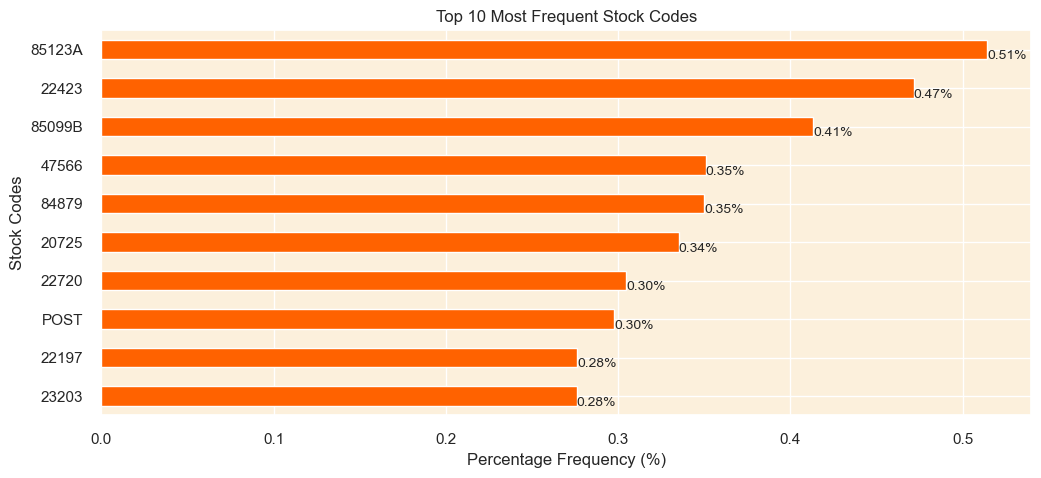

In [85]:
# Finding the top 10 most frequent stock codes
top_10_stock_codes = df["StockCode"].value_counts(normalize=True).head(10)*100
# Plotting the top 10 most frequent stock codes
plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh', color='#ff6200')

# Adding the percentage frequency on the bars
for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%', fontsize=10)

plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency (%)')
plt.ylabel('Stock Codes')
plt.gca().invert_yaxis()
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inferences on Stock Codes
</h2>

<p>
Product Variety:
The dataset includes 3,684 unique stock codes, reflecting a wide range of products offered by the online retail store. This level of diversity increases the potential to identify meaningful customer segments based on differing product preferences.

Popular Items:
Analyzing the top 10 most frequently occurring stock codes can provide valuable insights into the most popular products or categories, helping to understand purchasing trends and customer demand patterns.

Stock Code Anomalies:
While the majority of stock codes consist of 5 or 6 characters, certain irregular codes — such as 'POST' — are present. These likely represent non-product entries (e.g., postage or service-related transactions) rather than tangible goods. Since the objective of this project is to cluster customers based on product purchases and develop a recommendation system, such anomalies should be carefully examined and handled appropriately to preserve data quality and analytical accuracy.</p>

In [86]:
# Finding the number of numeric characters in each unique stock code
unique_stock_codes = df["StockCode"].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()
# Printing the value counts for unique stock codes
print("Value counts of numeric character frequencies in unique stock codes:")
print("-"*70)
print(numeric_char_counts_in_unique_codes)

Value counts of numeric character frequencies in unique stock codes:
----------------------------------------------------------------------
5    3676
0       7
1       1
Name: count, dtype: int64


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inferences on Stock Codes
</h2>

<p>

The results reveal the following observations:

The vast majority of unique stock codes (3,676 out of 3,684) consist of exactly five numeric characters, suggesting that this is the standard format used to represent product codes in the dataset.

A small number of anomalies are present: seven stock codes contain no numeric characters, and one stock code contains only a single numeric character. These clearly deviate from the expected format and require further examination to determine whether they correspond to valid product transactions or represent special cases (e.g., services, adjustments, or data entry inconsistencies).

To better understand these irregularities, the next step is to identify and review the stock codes containing zero or one numeric character.
<p>
</div>

In [87]:
# Finding and printing the stock codes with 0 and 1 numeric characters
anomalous_stock_codes = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

# Printing each stock code on a new line
print("Anomalous stock codes:")
print("-"*22)
for code in anomalous_stock_codes:
    print(code)

Anomalous stock codes:
----------------------
POST
D
C2
M
BANK CHARGES
PADS
DOT
CRUK


In [88]:
# Calculating the percentage of records with these stock codes
percentage_anomalous = (df['StockCode'].isin(anomalous_stock_codes).sum() / len(df)) * 100

# Printing the percentage
print(f"The percentage of records with anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with anomalous stock codes in the dataset is: 0.48%


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inference
</h2>

<p>
Based on the analysis, we find that a very small proportion of the records, 0.48%, have anomalous stock codes, which deviate from the typical format observed in the majority of the data. Also, these anomalous codes are just a fraction among all unique stock codes (only 8 out of 3684).

These codes seem to represent non-product transactions like "BANK CHARGES", "POST" (possibly postage fees), etc. Since they do not represent actual products and are a very small proportion of the dataset, including them in the analysis might introduce noise and distort the clustering and recommendation system.</p>

<p>Strategy:
Given the context of the project, where the aim is to cluster customers based on their product purchasing behaviors and develop a product recommendation system, it would be prudent to exclude these records with anomalous stock codes from the dataset. This way, the focus remains strictly on genuine product transactions, which would lead to a more accurate and meaningful analysis.
</p>

<p>Thus, the strategy would be to filter out and remove rows with these anomalous stock codes from the dataset before proceeding with further analysis and model development:</p>

In [89]:
# Removing rows with anomalous stock codes from the dataset
df = df[~df['StockCode'].isin(anomalous_stock_codes)]
# Getting the number of rows in the dataframe
df.shape[0]

399689

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Cleaning Description Column
</h2>

<p>First, I will calculate the occurrence count of each unique description in the dataset. Then, I will plot the top 30 descriptions. This visualization will give a clear view of the highest occurring descriptions in the dataset:
</p>


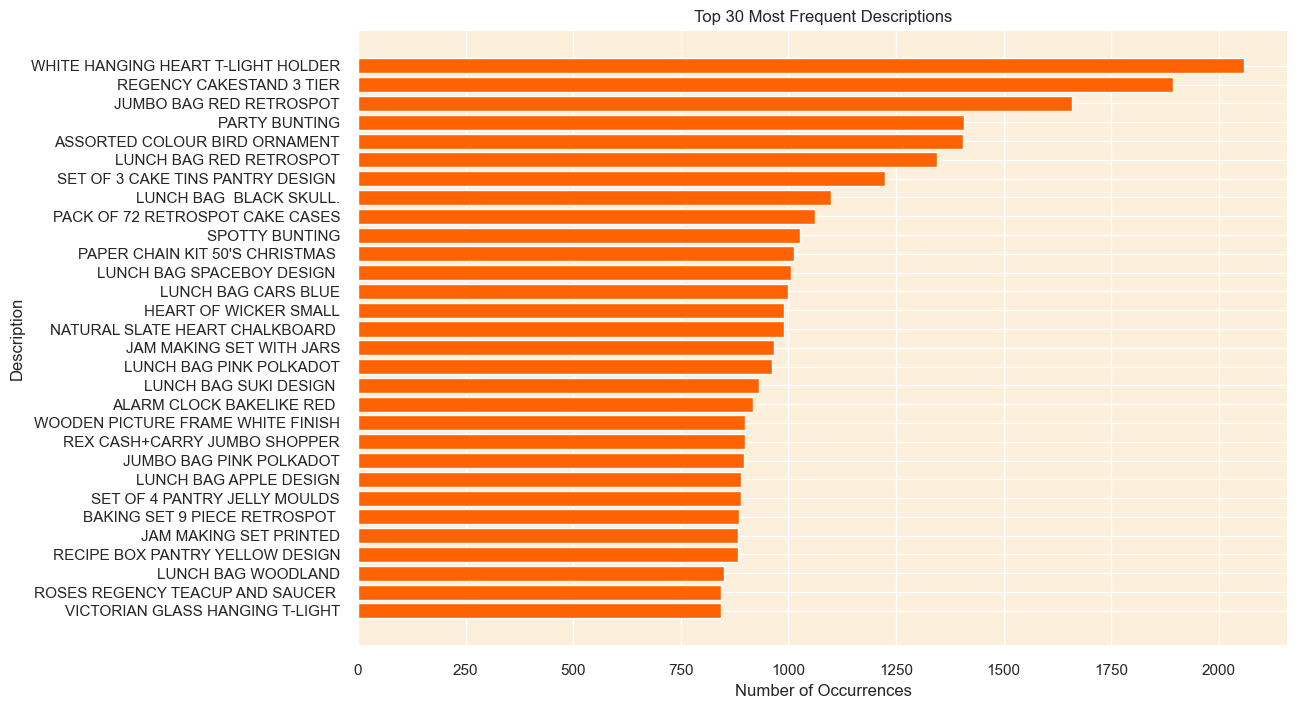

In [90]:
# Calculate the occurrence of each unique description and sort them
description_counts = df['Description'].value_counts()

# Get the top 30 descriptions
top_30_descriptions = description_counts[:30]

# Plotting
plt.figure(figsize=(12,8))
plt.barh(top_30_descriptions.index[::-1], top_30_descriptions.values[::-1], color='#ff6200')

# Adding labels and title
plt.xlabel('Number of Occurrences')
plt.ylabel('Description')
plt.title('Top 30 Most Frequent Descriptions')

# Show the plot
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inferences on Descriptions
</h2>

The most frequently occurring product descriptions mainly correspond to household items, particularly kitchenware, lunch bags, and decorative accessories, indicating strong customer demand in these categories.

Additionally, all product descriptions appear in uppercase, suggesting a standardized data entry format within the database. However, given the inconsistencies and anomalies previously identified in the dataset, it would be advisable to verify whether any descriptions exist in lowercase or mixed-case formats to ensure data consistency and

In [91]:
# Find unique descriptions containing lowercase characters
lowercase_descriptions = df['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]

# Print the unique descriptions containing lowercase characters
print("The unique descriptions containing lowercase characters are:")
print("-"*60)
for desc in lowercase_descriptions:
    print(desc)


The unique descriptions containing lowercase characters are:
------------------------------------------------------------
BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
3 TRADITIONAl BISCUIT CUTTERS  SET
NUMBER TILE COTTAGE GARDEN No
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
POLYESTER FILLER PAD 30CMx30CM
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inferences 
</h2>


After examining the descriptions containing lowercase characters, it becomes clear that some of these entries do not correspond to actual product names. Examples such as "Next Day Carriage" and "High Resolution Image" suggest that they represent service-related information or supplementary details rather than tangible products.

These entries are likely non-product transactions or system-generated descriptions and should be carefully reviewed to determine whether they should be excluded to maintain consistency and analytical relevance in the dataset.

<p>Strategy:</p>
<p>
Step 1: 
</p>
<p>
Remove the rows where the descriptions contain service-related information like "Next Day Carriage" and "High Resolution Image", as these do not represent actual products and would not contribute to the clustering and recommendation system we aim to build.
</p>
<p>
Step 2:
</p> 
<p>
For the remaining descriptions with mixed case, standardize the text to uppercase to maintain uniformity across the dataset. This will also assist in reducing the chances of having duplicate entries with different case styles.
By implementing the above strategy, we can enhance the quality of our dataset, making it more suitable for the analysis and modeling phases of our project.</p>

In [92]:
service_related_descriptions = ["Next Day Carriage", "High Resolution Image"]

# Calculate the percentage of records with service-related descriptions
service_related_percentage = df[df['Description'].isin(service_related_descriptions)].shape[0] / df.shape[0] * 100

# Print the percentage of records with service-related descriptions
print(f"The percentage of records with service-related descriptions in the dataset is: {service_related_percentage:.2f}%")

# Remove rows with service-related information in the description
df = df[~df['Description'].isin(service_related_descriptions)]

# Standardize the text to uppercase to maintain uniformity across the dataset
df['Description'] = df['Description'].str.upper()

The percentage of records with service-related descriptions in the dataset is: 0.02%


In [93]:
# Getting the number of rows in the dataframe
df.shape[0]

399606

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Treating Zero Unit Prices
</h2>

<p>let's take a look at the statistical description of the UnitPrice column:</p>

In [94]:
df["UnitPrice"].describe()

count    399606.000000
mean          2.904957
std           4.448796
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max         649.500000
Name: UnitPrice, dtype: float64

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inference:
</h2>

<p>
The minimum unit price value is zero. This suggests that there are some transactions where the unit price is zero, potentially indicating a free item or a data entry error. To understand their nature, it is essential to investigate these zero unit price transactions further. A detailed analysis of the product descriptions associated with zero unit prices will be conducted to determine if they adhere to a specific pattern:</p>

In [95]:
df[df["UnitPrice"] == 0].describe()[["Quantity"]]

,Quantity
count,33.000000
mean,420.515152
std,2176.713608
min,1.000000
25%,2.000000
50%,11.000000
75%,36.000000
max,12540.000000


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inference on UnitPrice
</h2> 
<p>
Transactions with a unit price equal to zero are relatively rare, totaling only 33 instances in the dataset. However, these transactions exhibit significant variability in quantity, ranging from 1 to 12,540 units, with a notably high standard deviation.

Such extreme variation, combined with a zero unit price, suggests that these entries may represent special cases (e.g., promotional items, free samples, adjustments, or data entry errors). Including them in the clustering process could introduce noise and potentially distort the patterns of customer purchasing behavior identified by the model.

Therefore, these zero-priced transactions should be carefully examined and appropriately handled before proceeding with clustering analysis.
</p>

<p>
Strategy:
Given the small number of these transactions and their potential to introduce noise in the data analysis, the strategy should be to remove these transactions from the dataset. This would help in maintaining a cleaner and more consistent dataset, which is essential for building an accurate and reliable clustering model and recommendation system.
</p>

In [96]:
# Removing records with a unit price of zero to avoid potential data entry errors
df = df[df['UnitPrice'] > 0]

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Outlier Treatment
</h2> 

In K-means clustering, the algorithm is sensitive to both the scale of data and the presence of outliers, as they can significantly influence the position of centroids, potentially leading to incorrect cluster assignments. However, considering the context of this project where the final goal is to understand customer behavior and preferences through K-means clustering, it would be more prudent to address the issue of outliers after the feature engineering phase where we create a customer-centric dataset. At this stage, the data is transactional, and removing outliers might eliminate valuable information that could play a crucial role in segmenting customers later on. Therefore, we will postpone the outlier treatment and proceed to the next stage for now.

In [97]:
#resetting the index
df.reset_index(drop=True, inplace=True)
#the number of row in the dataframe
df.shape

(399573, 9)

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Feature Engineering
</h2> 
<p>In order to create a comprehensive customer-centric dataset for clustering and recommendation, the following features can be engineered from the available data: rewrite and modify completely in simple english</p>
<p>Feature engineering is the process of creating new useful variables from existing data to improve analysis or machine learning models.</p>

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
RFM Features
</h2> 

<p>RFM Analysis is a customer segmentation technique used to evaluate customer value based on purchasing behavior. The acronym RFM represents three key metrics:

Recency (R): Measures how recently a customer made their last purchase. Customers who purchased more recently are generally more engaged and responsive to marketing efforts.

Frequency (F): Indicates how often a customer makes purchases within a given time period. Higher frequency reflects stronger engagement, loyalty, and consistent interaction with the business.

Monetary (M): Represents the total amount a customer has spent over a specific period. Customers with higher monetary values typically contribute more revenue and may have a higher lifetime value.

By combining these three dimensions, RFM analysis provides a structured way to understand customer behavior, identify high-value segments, and design targeted marketing strategies. It also serves as a strong foundation for building effective recommendation systems and personalized customer experiences.


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Recency (R)
</h2>
In this step, we analyze how recently each customer made a purchase, which is an important factor in customer segmentation.

Days Since Last Purchase is defined as the number of days between a customer’s most recent transaction and a reference date. A lower value indicates recent activity and higher engagement, while a higher value may suggest reduced interaction. This metric helps businesses identify inactive customers and design targeted strategies to improve retention and loyalty.

In [98]:
#Convert InvoiceDate to Datatime type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]) 
# #convert InvoiceDate to Datetime and extract only the date
df["InvoiceDay"] = df["InvoiceDate"].dt.date

# #Find the most recent purchase date for each customers 
customer_data = df.groupby("CustomerID")["InvoiceDay"].max().reset_index()
# #Find the most reset data in the entire dataset
most_resent_data = df["InvoiceDay"].max()
#Convert InvoiceDay to datetime before subtraction
customer_data["InvoiceDay"] = pd.to_datetime(customer_data["InvoiceDay"])
most_resent_data = pd.to_datetime(most_resent_data)
# calculate the number of days since the last purchase for each customers 
customer_data["Days_since_Last_Purchase"] = (most_resent_data-customer_data["InvoiceDay"]).dt.days
#Remove InvoiceDay column
customer_data.drop(columns=["InvoiceDay"], inplace=True)


In [99]:
customer_data.head()

,CustomerID,Days_since_Last_Purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Frequency (F)
</h2>
<p>In this step, two features are created to measure customer purchase frequency:

Total Transactions: The total number of purchases made by a customer, reflecting their engagement with the retailer.

Total Products Purchased: The total quantity of products bought across all transactions, showing the customer’s buying volume.

These features help segment customers by purchase frequency, supporting targeted marketing and personalized recommendations.</p>


In [100]:
# Calculate the total number of transactions. 
total_transactions = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
#rename InvoiceNo to Total_Transactions
total_transactions.rename(columns= {"InvoiceNo" : "Total_Transactions"}, inplace=True)

# Calculate the total number of products purchased by the each customer
total_products_purchased = df.groupby("CustomerID")["Quantity"].sum().reset_index()
#rename Quantity to Total_Products_Purchased
total_products_purchased.rename(columns={"Quantity":"Total_Products_Purchased"}, inplace=True)

#merge the new feature with the customer dataframe
customer_data = pd.merge(customer_data, total_transactions, on="CustomerID")
customer_data = pd.merge(customer_data, total_products_purchased, on="CustomerID")

# display the first few rows
customer_data.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,0
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Monetary (M)
</h2>
<p>In this step, two features are created to capture the monetary value of customer transactions:

Total Spend: The total amount spent by a customer, calculated as the sum of UnitPrice × Quantity across all their transactions. It reflects the customer’s overall value to the business.

Average Transaction Value: The Total Spend divided by Total Transactions, showing the average value of each purchase. This helps understand customer spending behavior and supports targeted marketing strategies.</p>


In [101]:
#Calculate the total spend by each customer 
df["Total_Spend"] = df["UnitPrice"] * df["Quantity"]
total_spend = df.groupby("CustomerID")["Total_Spend"].sum().reset_index()

#Calculate the average transactions for each customer
average_transaction_value = total_spend.merge(total_transactions, on='CustomerID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']

#merge the new feature in to the customer dataframe
customer_data = pd.merge(customer_data, total_spend, on="CustomerID")
customer_data = pd.merge(customer_data, average_transaction_value[["CustomerID", "Average_Transaction_Value"]] , on="CustomerID")
#few rows of customer_data dataframe
customer_data.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,12346.0,325,2,0,0.00,0.000000
1,12347.0,2,7,2458,4310.00,615.714286
2,12348.0,75,4,2332,1437.24,359.310000
3,12349.0,18,1,630,1457.55,1457.550000
4,12350.0,310,1,196,294.40,294.400000


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Product Diversity
</h2>

<p>
In this step, we analyze how varied each customer’s purchases are.

Unique Products Purchased: The number of different products bought by a customer. A higher value suggests diverse buying preferences, while a lower value indicates more specific or focused interests.

This feature helps segment customers based on purchase diversity and improves personalized product recommendations.
</p>

In [102]:
#Calculate the number of unique products purchased by each customer
unique_products_purchased = df.groupby("CustomerID")["StockCode"].nunique().reset_index()
unique_products_purchased.rename(columns={"StockCode" : "Unique_Products_Purchased"}, inplace=True)

#merge the new feature in to the customer_data dataframe
customer_data = pd.merge(customer_data, unique_products_purchased, on="CustomerID")
customer_data.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,12346.0,325,2,0,0.00,0.000000,1
1,12347.0,2,7,2458,4310.00,615.714286,103
2,12348.0,75,4,2332,1437.24,359.310000,21
3,12349.0,18,1,630,1457.55,1457.550000,72
4,12350.0,310,1,196,294.40,294.400000,16


 <div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Behavioral Features
</h2>
<p>
In this step, we create features to capture customer shopping behavior and timing patterns:

<strong>Average Days Between Purchases:</strong> The average time a customer takes between purchases, helping predict future buying activity and plan targeted promotions.

<strong>Favorite Shopping Day: </strong> The day of the week a customer shops most often, useful for optimizing weekly marketing strategies.

<strong>Favorite Shopping Hour:</strong>  The hour of the day a customer is most active, helping schedule campaigns at peak engagement times.

These behavioral features provide a deeper understanding of customer habits and improve the quality of clustering and segmentation.
</p>

In [103]:
#extract days of the week and hour from InvoiceDate
df["Day_Of_Week"]  = df["InvoiceDate"].dt.dayofweek
df["Hour"] = df["InvoiceDate"].dt.hour

#Calculate average number of days between consecutive purchase

days_between_purchases = df.groupby("CustomerID")["InvoiceDay"].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))  
                                                                                       
average_days_between_purchases = days_between_purchases.groupby("CustomerID").mean().reset_index()
average_days_between_purchases.rename(columns={'InvoiceDay': 'Average_Days_Between_Purchases'}, inplace=True)

#find favorite shopping day of the week
favorite_shopping_day = (
    df.groupby(["CustomerID", "Day_Of_Week"])
      .size()
      .reset_index(name="Count")
      .loc[lambda x: x.groupby("CustomerID")["Count"].idxmax(),
           ["CustomerID", "Day_Of_Week"]]
)

#find favorite shopping houre of the day
favorite_shopping_hour = (
    df.groupby(["CustomerID", "Hour"])
    .size()
    .reset_index(name="Count")
    .loc[lambda x: x.groupby("CustomerID")["Count"].idxmax(),
           ["CustomerID", "Hour"]]
)

# merge the new feature to the Customer_data DataFrame

customer_data = pd.merge(customer_data, average_days_between_purchases, on="CustomerID")
customer_data = pd.merge(customer_data, favorite_shopping_day, on="CustomerID")
customer_data = pd.merge(customer_data, favorite_shopping_hour, on="CustomerID")

 #the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,0,9
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,2,16



<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Geographic Features
</h2>
<p>
In this step, we add a geographic feature to capture customer location:

Country: Indicates the country where each customer is based. This helps identify regional purchasing patterns and preferences. It also supports targeted marketing, better inventory planning, and improved logistics and delivery strategies for different locations.

In [104]:
df["Country"].value_counts(normalize=True).head()

Country
United Kingdom    0.890971
Germany           0.022722
France            0.020402
EIRE              0.018440
Spain             0.006162
Name: proportion, dtype: float64

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Geographic Features inference
</h2>

<p>Since the majority of transactions (89%) come from the United Kingdom, it may be useful to create a binary feature indicating whether a transaction is from the UK or not. This simplifies the geographic information, reducing dimensionality while retaining key location insights, which is especially helpful for algorithms like K-means that are sensitive to high-dimensional data.
</p>

<p>
Methodology

Group Transactions: Group the data by CustomerID and Country to count the number of transactions per country for each customer.

Identify Main Country: Determine the primary country for each customer, based on where they have made the most transactions.

Create Binary Feature: Add a column indicating whether the customer is from the UK (1) or not (0).

Merge with Customer Data: Integrate this new feature into the customer_data dataframe for use in further analysis and modeling.
</p>

In [105]:
#get the number of transactions per country for each customer
customer_country = df.groupby(["CustomerID", "Country"]).size().reset_index(name="Number_of_Transactions")

#get the country with maximum transactions per customer if the customer has transactions from multiple country
customer_main_country = customer_country.sort_values("Number_of_Transactions", ascending=False).drop_duplicates("CustomerID")

#identify weather the customer is from UK
customer_main_country["Is_UK"] = customer_main_country["Country"].apply(lambda x: 1 if x== "United Kingdom" else 0)

#merge the data with the customer_data dataframe
customer_data = pd.merge(customer_data, customer_main_country[["CustomerID", "Is_UK"]], on="CustomerID", how="left")

 #the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,0,9,0
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,2,16,0


In [106]:
#display feature distribution
customer_data["Is_UK"].value_counts()

Is_UK
1    3866
0     416
Name: count, dtype: int64

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Cancellation Insights
</h2>

<p>
At this stage, I will further analyze customer cancellation behavior to strengthen the segmentation model. I will introduce two new features:

Cancellation Frequency: The total number of canceled transactions per customer. This helps identify customers who frequently cancel, which may signal dissatisfaction or recurring issues.

Cancellation Rate: The percentage of canceled transactions out of a customer’s total transactions. This provides a normalized measure of cancellation behavior, making it easier to compare customers fairly.

Adding these features will give a clearer understanding of customer behavior and support more accurate and actionable segmentation.
</p>

In [107]:
#calculate the total transaction made by customer
total_transactions = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()

#calculate number of cancelled transactions 
cancelled_transactions = df[df["Transaction_Status"] == "Cancelled"]
cancellation_frequency = cancelled_transactions.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
cancellation_frequency.rename(columns={"InvoiceNo" : "Cancellation_Frequency"}, inplace=True)

# #merge cancellation frequency to customerdata dataframe
customer_data = pd.merge(customer_data, cancellation_frequency, on="CustomerID", how="left")

# #replace NaN value with 0 fot the customer who haven't cancelled any transaction  
customer_data["Cancellation_Frequency"].fillna(0, inplace=True)

# #calculate the cancellation rate
customer_data["Cancellation_rate"] = customer_data["Cancellation_Frequency"]/ total_transactions["InvoiceNo"]
# #display some rows from customerdata dataframe
customer_data.head()


,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_rate
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1,1.0,0.5
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0,0.0,0.0
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0,0.0,0.0
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,0,9,0,0.0,0.0
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,2,16,0,0.0,0.0


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Seasonality & Trends
</h2>

<p>
In this step, I will analyze seasonality and spending trends to better understand customer purchasing behavior and improve segmentation. The new features include:

Monthly_Spending_Mean: The average amount a customer spends per month, helping identify high-value versus budget-conscious customers.

Monthly_Spending_Std: The variation in monthly spending, showing whether a customer spends consistently or makes irregular large purchases.

Spending_Trend: The overall direction of spending over time (increasing, decreasing, or stable), indicating changes in engagement or loyalty.

By adding these features, we can build more precise customer segments and design more targeted, effective marketing strategies.

</p>

In [108]:
 #Extract month and year from InvoiceDate
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

#calculate monthly spend
monthly_spending = df.groupby(["CustomerID", "Year", "Month"])["Total_Spend"].sum().reset_index()
#To calculate seasonal buying patterns, we are using the monthly frequency pattern as a proxy for the seasonal buying patterns.
seasonal_buying_patterns = monthly_spending.groupby("CustomerID")["Total_Spend"].agg(["mean", "std"]).reset_index()
seasonal_buying_patterns.rename(columns={"mean":'Monthly_Spending_Mean', 'std': 'Monthly_Spending_Std'}, inplace=True)

#replay NaN value in Monthly Spending Mean with 0 implying no no variability for customers in single month 
seasonal_buying_patterns["Monthly_Spending_Std"].fillna(0, inplace=True)

#calculate trends in spending 
#to calculate the spending trend, we are using the slop of linear trend line fitted to custmors spending over time 
def calculate_trends(spending_data):
    # If there are more than one data points, we calculate the trend using linear regression
    if len(spending_data) > 1:
        x = np.arange(len(spending_data))
        slope, _, _, _, _ = linregress(x, spending_data)
        return slope
    else:
        return 0
#apply calculate trend function to find spending trend of each customers 
spending_trends = monthly_spending.groupby("CustomerID")["Total_Spend"].apply(calculate_trends).reset_index()
spending_trends.rename(columns={'Total_Spend': 'Spending_Trend'}, inplace=True)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='CustomerID')
customer_data = pd.merge(customer_data, spending_trends, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1,1.0,0.5,0.000000,0.000000,0.000000
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0,0.0,0.0,615.714286,341.070789,4.486071
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0,0.0,0.0,359.310000,203.875689,-100.884000
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,0,9,0,0.0,0.0,1457.550000,0.000000,0.000000
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,2,16,0,0.0,0.0,294.400000,0.000000,0.000000


In [109]:
# Changing the data type of 'CustomerID' to string as it is a unique identifier and not used in mathematical operations
customer_data['CustomerID'] = customer_data['CustomerID'].astype(str)

# Convert data types of columns to optimal types
customer_data = customer_data.convert_dtypes()

In [110]:
customer_data.head(10)

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,2,0,0.0,0.0,1,0.0,1,10,1,1,0.5,0.0,0.0,0.0
1,12347.0,2,7,2458,4310.0,615.714286,103,2.016575,1,14,0,0,0.0,615.714286,341.070789,4.486071
2,12348.0,75,4,2332,1437.24,359.31,21,10.884615,3,19,0,0,0.0,359.31,203.875689,-100.884
3,12349.0,18,1,630,1457.55,1457.55,72,0.0,0,9,0,0,0.0,1457.55,0.0,0.0
4,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,0,0.0,294.4,0.0,0.0
5,12352.0,36,8,463,1265.41,158.17625,57,3.13253,1,14,0,1,0.125,316.3525,134.700629,9.351
6,12353.0,204,1,20,89.0,89.0,4,0.0,3,17,0,0,0.0,89.0,0.0,0.0
7,12354.0,232,1,530,1079.4,1079.4,58,0.0,3,13,0,0,0.0,1079.4,0.0,0.0
8,12355.0,214,1,240,459.4,459.4,13,0.0,0,13,0,0,0.0,459.4,0.0,0.0
9,12356.0,22,3,1573,2487.43,829.143333,52,5.315789,1,9,0,0,0.0,829.143333,991.462585,-944.635


In [111]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4282 entries, 0 to 4281
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      4282 non-null   string 
 1   Days_since_Last_Purchase        4282 non-null   Int64  
 2   Total_Transactions              4282 non-null   Int64  
 3   Total_Products_Purchased        4282 non-null   Int64  
 4   Total_Spend                     4282 non-null   Float64
 5   Average_Transaction_Value       4282 non-null   Float64
 6   Unique_Products_Purchased       4282 non-null   Int64  
 7   Average_Days_Between_Purchases  4282 non-null   Float64
 8   Day_Of_Week                     4282 non-null   Int32  
 9   Hour                            4282 non-null   Int32  
 10  Is_UK                           4282 non-null   Int64  
 11  Cancellation_Frequency          4282 non-null   Int64  
 12  Cancellation_rate               42

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Customer Dataset Description:
</h2>

<table style="
    width: 100%;
    border-collapse: collapse;
    color: #c7d2fe;
">
    <thead>
        <tr>
            <th style="border-bottom: 2px solid #38bdf8; padding: 10px; text-align:left;">Variable</th>
            <th style="border-bottom: 2px solid #38bdf8; padding: 10px; text-align:left;">Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">CustomerID</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Identifier uniquely assigned to each customer, used to distinguish individual customers.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Days_Since_Last_Purchase</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The number of days that have passed since the customer's last purchase.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Total_Transactions</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The total number of transactions made by the customer.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Total_Products_Purchased</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The total quantity of products purchased by the customer across all transactions.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Total_Spend</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The total amount of money the customer has spent across all transactions.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Average_Transaction_Value</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The average value of the customer's transactions, calculated as total spend divided by the number of transactions.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Unique_Products_Purchased</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The number of different products the customer has purchased.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Average_Days_Between_Purchases</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The average number of days between consecutive purchases made by the customer.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Day_Of_Week</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The day of the week when the customer prefers to shop, represented numerically (0 for Monday, 6 for Sunday).</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Hour</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The hour of the day when the customer prefers to shop, represented in a 24-hour format.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Is_UK</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">A binary variable indicating whether the customer is based in the UK (1) or not (0).</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Cancellation_Frequency</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The total number of transactions that the customer has cancelled.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Cancellation_Rate</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The proportion of transactions that the customer has cancelled, calculated as cancellation frequency divided by total transactions.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Monthly_Spending_Mean</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The average monthly spending of the customer.</td>
        </tr>
        <tr>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">Monthly_Spending_Std</td>
            <td style="padding: 8px; border-bottom: 1px solid #334155;">The standard deviation of the customer's monthly spending, indicating the variability in their spending pattern.</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Spending_Trend</td>
            <td style="padding: 8px;">A numerical representation of the trend in the customer's spending over time. A positive value indicates an increasing trend, a negative value indicates a decreasing trend, and a value close to zero indicates a stable trend.</td>
        </tr>
    </tbody>
</table>

<p>We’ve successfully built a customer-focused dataset enriched with meaningful features that capture buying behavior and preferences.

Next, we will:

Explore the data to uncover key patterns and trends.

Detect and handle outliers to improve data quality.

Prepare and scale the data for clustering.

These steps will ensure a solid foundation for effective customer segmentation and the development of a personalized recommendation system.
</div>

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Outlier Detection and Treatment
</h2>
<p>
Identify and handle outliers in the dataset.

Outliers are data points that significantly differ from the majority and can distort analysis results.

In k-means clustering, outliers can shift cluster centroids and reduce accuracy.

Use the Isolation Forest algorithm to detect outliers in multi-dimensional data.

Isolation Forest isolates anomalies by randomly selecting features and split values.
</p>


In [112]:
# Create the Isolation Forest model, assuming 5% of the data may be outliers
model = IsolationForest(contamination=0.05, random_state=0)

# Train the model on the feature columns (excluding the first column) and convert the DataFrame to NumPy format to avoid warnings
customer_data["Outlier_Scores"] = model.fit_predict(customer_data.iloc[:, 1:].to_numpy())

## Creating a new column to identify outliers (1 for inliers and -1 for outliers)
customer_data["Is_Outlier"] = [ 1 if x ==-1 else 0 for x in customer_data["Outlier_Scores"]] 

## Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Outlier_Scores,Is_Outlier
0,12346.0,325,2,0,0.0,0.0,1,0.0,1,10,1,1,0.5,0.0,0.0,0.0,1,0
1,12347.0,2,7,2458,4310.0,615.714286,103,2.016575,1,14,0,0,0.0,615.714286,341.070789,4.486071,1,0
2,12348.0,75,4,2332,1437.24,359.31,21,10.884615,3,19,0,0,0.0,359.31,203.875689,-100.884,1,0
3,12349.0,18,1,630,1457.55,1457.55,72,0.0,0,9,0,0,0.0,1457.55,0.0,0.0,1,0
4,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,0,0.0,294.4,0.0,0.0,1,0


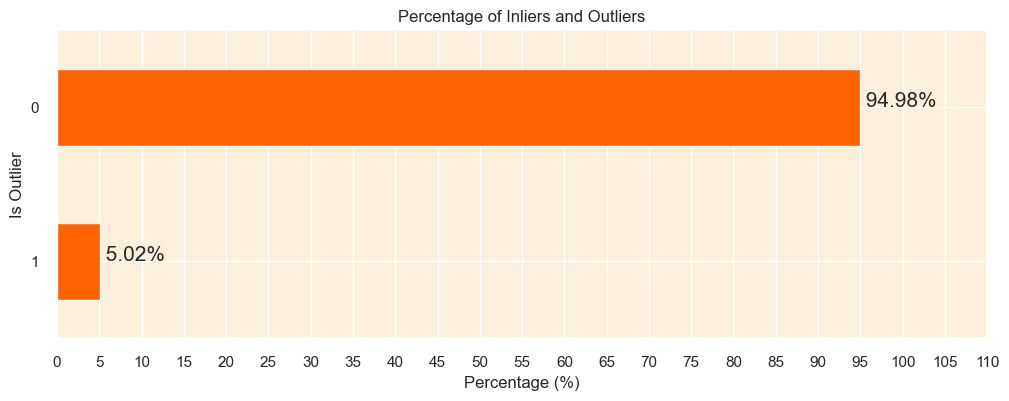

In [113]:
# Calculate the percentage of outliers
outlier_percentage = customer_data["Is_Outlier"].value_counts(normalize=True) * 100

# Plotting the percentage of outlier 
plt.figure(figsize=(12, 4))
outlier_percentage.plot(kind="barh", color = "#ff6200")

# Adding the percentage labels on the bars 
for index, value in enumerate(outlier_percentage):
    plt.text(value, index, f"{value: .2f}%", fontsize = 15)

plt.title('Percentage of Inliers and Outliers')
plt.xticks(ticks=np.arange(0, 115, 5))
plt.xlabel('Percentage (%)')
plt.ylabel('Is Outlier')
plt.gca().invert_yaxis()
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inference:
</h2>
<p>
Approximately 5% of customers were detected as outliers, which is a balanced proportion. This indicates the Isolation Forest model effectively identified unusual data points without excessively reducing the dataset.

Strategy:
To ensure accurate customer segmentation, the detected outliers will be separated for further review and removed from the main dataset. The auxiliary columns (Outlier_Scores and Is_Outlier) will also be dropped before proceeding with clustering.

In [114]:
#Separate the outlier for analysis 
outliers_data = customer_data[customer_data["Is_Outlier"] == 1]

#Remove the outliers from the main dataset
customer_data_cleaned  = customer_data[customer_data["Is_Outlier"] == 0]

#Drop the Outlier_Score and Is_Outlier columns
customer_data_cleaned = customer_data_cleaned.drop(columns=["Outlier_Scores", "Is_Outlier"])

#Reset the index of the cleaned data 
customer_data_cleaned.reset_index(drop=True, inplace=True)


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">

</h2>
<p>
The outliers have been isolated and removed, leaving a clean dataset ready for feature scaling and clustering to identify customer segments.

In [115]:
# Getting the number of rows in the cleaned customer dataset
customer_data_cleaned.shape[0]

4067

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Correlation Analysis
</h2>

<p>Before applying KMeans, we need to examine feature correlations to detect multicollinearity. Highly correlated variables can distort clustering results by adding redundant information and reducing cluster clarity.

If strong correlations are found, we can apply dimensionality reduction techniques such as PCA to transform correlated features into uncorrelated components while preserving most of the variance. This improves cluster quality and computational efficiency.</p>

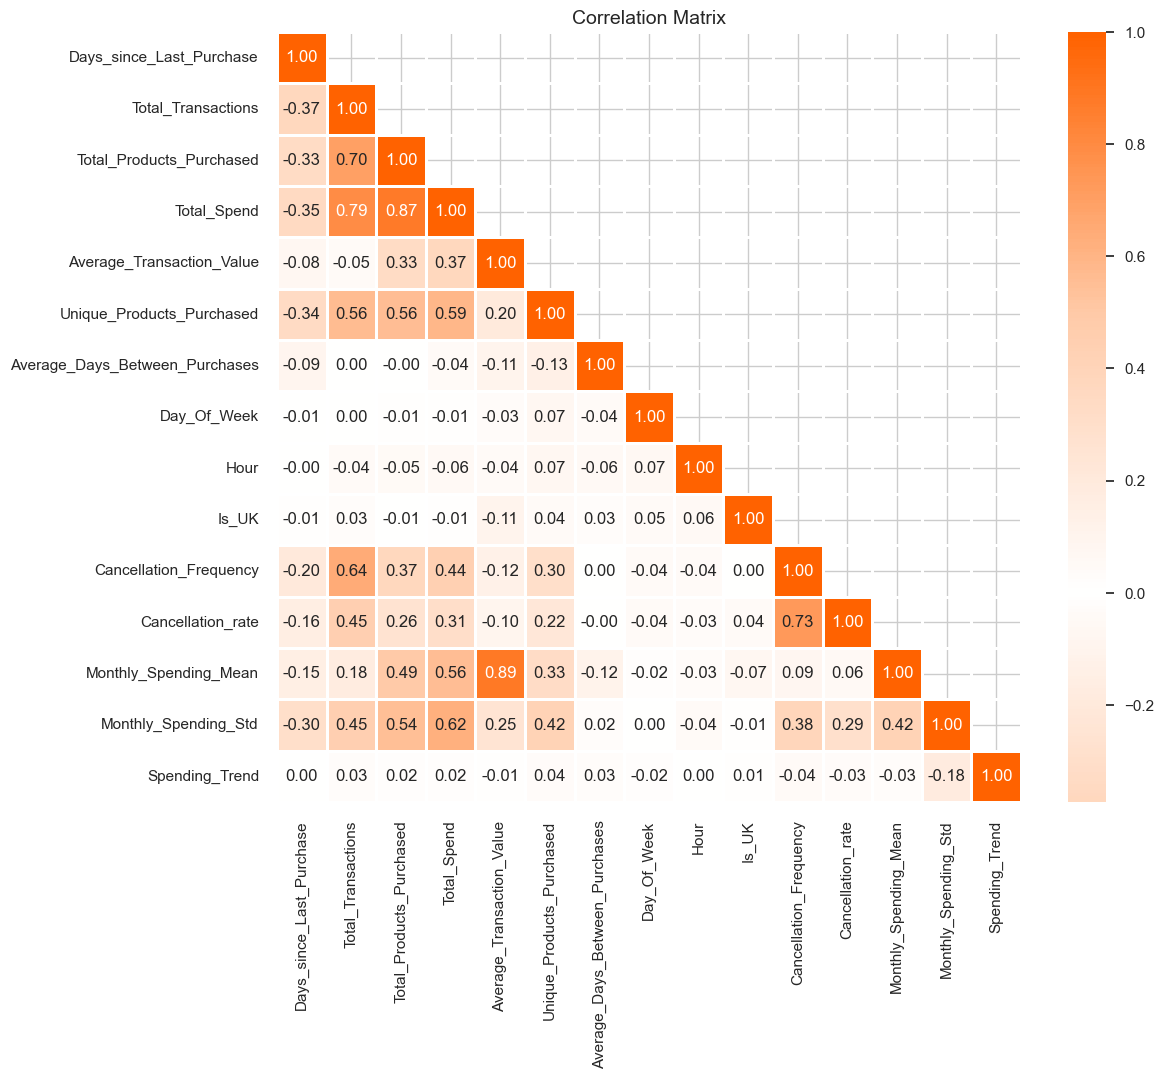

In [116]:
#Reset background style 
sns.set_style("whitegrid")

#calculate the correlation matrix 
corr = customer_data_cleaned.drop(columns=["CustomerID"]).corr()

# Define a custom colormap
colors = ['#ff6200', '#ffcaa8', 'white', '#ffcaa8', '#ff6200']
my_cmap = LinearSegmentedColormap.from_list('custom_map', colors, N=256)

# Create a mask to only show the lower triangle of the matrix 
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap=my_cmap, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inference
</h2>
<p> 

The heatmap shows several strongly correlated feature pairs, such as:

Monthly_Spending_Mean and Average_Transaction_Value

Total_Spend and Total_Products_Purchased

Total_Transactions and Total_Spend

Cancellation_Rate and Cancellation_Frequency

Total_Transactions and Total_Products_Purchased

</p>

<p>Before proceeding with KMeans, it is advisable to address multicollinearity, as correlated features can bias distance calculations and affect cluster stability. Applying a dimensionality reduction technique such as PCA will transform the correlated variables into uncorrelated components, leading to more stable and meaningful clustering results.</p>

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Feature Scaling
</h2>
<p> 

<p style="
color: #fffb00;
">
Feature scaling is the process of adjusting data features to a common scale so they contribute equally to a model.</p>

Before applying clustering or dimensionality reduction, feature scaling is essential.

K-means: Since K-means groups data based on distance, features with larger scales can dominate the results and distort the clusters.

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms data into a smaller set of new variables (principal components) that capture the most variance in the dataset.

PCA: PCA identifies directions of maximum variance. Without scaling, features with larger values can overly influence the principal components, masking the true data structure.

Scaling ensures all features contribute equally and improves model accuracy.

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Methodology
</h2>
<p> 


To ensure fair contribution of features and reveal true data patterns, I will standardize the data by transforming the relevant features to have a mean of 0 and a standard deviation of 1.

However, some features will not be scaled:

CustomerID: It is only an identifier and has no analytical value for clustering.

Is_UK: It is a binary variable (0 or 1), so scaling is unnecessary.

Day_Of_Week: It represents a categorical variable encoded as numbers (1–7), so scaling is not appropriate.

All other relevant numerical features will be scaled before applying PCA and K-means.

In [117]:
#Initialize the StandardScaler
scaler = StandardScaler()
#List of columns that don't need to be scaled
columns_to_exclude = ["CustomerID", "Is_UK", "Day_Of_Week"]

#List of column that need to be scaled
# columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)

columns_to_scale = [
    col for col in customer_data_cleaned.columns
    if col not in columns_to_exclude

]

#Copy the cleaned dataset
customer_data_scaled = customer_data_cleaned.copy()

#Applying the scaler to the necessary columns in the data set 
customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])

#Display the first few raw of scaled data
customer_data_scaled.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,2.345802,-0.477589,-0.754491,-0.813464,-1.317106,-0.908471,-0.310564,1,-1.086929,1,0.420541,0.417623,-1.329018,-0.713318,0.090868
1,12347.0,-0.905575,0.707930,2.005048,2.366920,1.528132,0.815119,-0.128438,1,0.647126,0,-0.545753,-0.432111,0.989511,1.259961,0.116774
2,12348.0,-0.170744,-0.003381,1.863591,0.247087,0.343279,-0.570512,0.672476,3,2.814696,0,-0.545753,-0.432111,0.023997,0.466213,-0.491708
3,12349.0,-0.744516,-0.714692,-0.047205,0.262074,5.418285,0.291283,-0.310564,0,-1.520443,0,-0.545753,-0.432111,4.159521,-0.713318,0.090868
4,12350.0,2.194809,-0.714692,-0.534446,-0.596223,0.043327,-0.655002,-0.310564,2,1.514154,0,-0.545753,-0.432111,-0.220428,-0.713318,0.090868


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Dimensionality Reduction
</h2>

<p>
Dimensionality reduction helps remove multicollinearity and redundant information in the dataset. It improves K-means clustering by focusing on the most meaningful patterns, reduces noise for more stable results, enables clear 2D or 3D visualization of customer segments, and increases computational efficiency.

Reduce Multicollinearity: Removes redundant features and minimizes correlation issues.

Improve K-means Clustering: Helps create more compact and well-separated clusters.

Reduce Noise: Focuses on the most important information for better accuracy.

Better Visualization: Makes it easier to plot and understand customer segments in 2D or 3D.

Increase Efficiency: Reduces computation time and improves model performance.

Now, we can choose an appropriate dimensionality reduction method.
</p>

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Which Dimensionality Reduction Method?
</h2>

<p>

Among methods like KernelPCA, ICA, ISOMAP, t-SNE, and UMAP, I will start with PCA (Principal Component Analysis).

Handles Multicollinearity: PCA is effective for datasets with correlated features.

Captures Linear Patterns: It works well when relationships in the data are mostly linear.

Reduces Features Efficiently: Keeps most of the important information while lowering dimensionality.

Computationally Fast: Does not significantly increase processing time.

If PCA does not retain enough variance, we may explore non-linear methods (e.g., t-SNE or UMAP) to capture more complex patterns, though they require more computation.

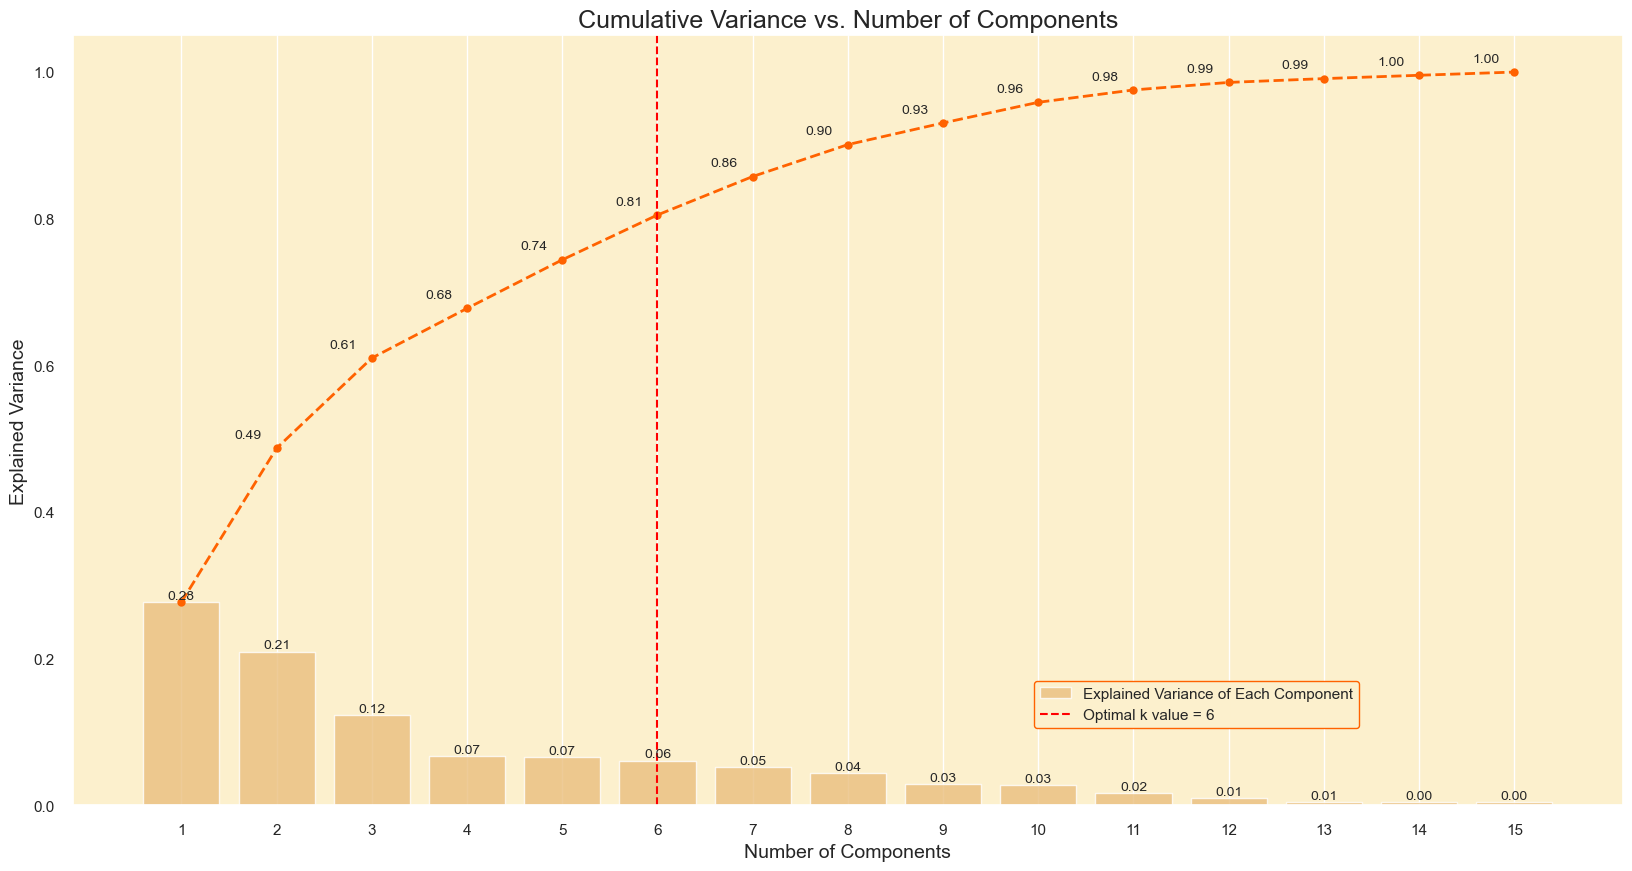

In [118]:
#Setting CustomerID  as the index Column
customer_data_scaled.set_index("CustomerID", inplace=True)

#apply PCA
pca = PCA().fit(customer_data_scaled)

#calculate the comulative sum of explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# set optimal k value
optimal_k = 6

#seaborn style
sns.set(rc={"axes.facecolor" : "#fcf0cd"}, style="darkgrid")

#plot cumulative explained variance vs number of component
plt.figure(figsize=(20,10))

#barchat that explained cumulative variance of the componenet
barplot = sns.barplot(x=list(range(1, len(cumulative_explained_variance) + 1)),
                      y=explained_variance_ratio,
                      color="#fcc36d",
                      alpha = 0.8                     
                      )

#Line plot for the cumulative explained variance
lineplot = plt.plot(range(0, len(cumulative_explained_variance)),
                    cumulative_explained_variance,
                    marker = "o", linestyle = "--", color="#ff6200", linewidth = 2
                    )

#plot optimal k value line 
optimal_k_line = plt.axvline(optimal_k-1, color="red", linestyle="--", label = f"Optimal k value= {optimal_k}")

#set title and label
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Cumulative Variance vs. Number of Components', fontsize=18)

#Customise ticks and legends
plt.xticks(range(0, len(cumulative_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot, optimal_k_line],
           labels=['Explained Variance of Each Component', 'Cumulative Explained Variance', f'Optimal k value = {optimal_k}'],
           loc=(0.62, 0.1),
           frameon = True,
           framealpha = 1.0,
           edgecolor='#ff6200'
           )

#display the variance value for the both on the plot
x_offset = -0.3
y_offset = 0.01
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f"{ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)
    if i > 0:
        plt.text(i + x_offset, cum_ev_ratio + y_offset, f"{cum_ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis='both')   
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Which Dimensionality Reduction Method?
</h2>

<p>Conclusion

The explained variance results show how much information each principal component captures from the dataset.

PC1 explains about 28% of the variance.

The first two components explain about 49%.

The first three explain about 61%.

By the sixth component, about 81% of the total variance is captured.

The cumulative variance curve begins to level off after the 6th component, indicating diminishing returns from adding more components (the “elbow” point).

For customer segmentation, retaining 6 principal components provides a good balance between preserving most of the information and reducing dimensionality.

In [119]:
#create a PCA for 6 components 
pca = PCA(n_components=6)

#fitting and transforming the original data to the new PCA
customer_data_pca = pca.fit_transform(customer_data_scaled)

#Create new dataframe from the PCA dataframe 
customer_data_pca = pd.DataFrame(customer_data_pca, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

#adding the CustomerID index back to new PCA dataframe
customer_data_pca.index = customer_data_scaled.index

In [120]:
# display dataframe based on the PCs
customer_data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
CustomerID,,,,,,
12346.0,-2.186469,-1.705370,-1.576745,-1.008187,-0.411803,-1.658012
12347.0,3.290264,-1.387375,1.923310,0.930990,-0.010591,0.873150
12348.0,0.584684,0.585019,0.664727,0.655411,-0.470280,2.306657
12349.0,1.791116,-2.695652,5.850040,-0.853418,0.677111,-1.520098
12350.0,-1.997139,-0.542639,0.578781,-0.183682,-1.484838,0.062672


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">

</h2>
Next, we examine the principal component loadings to see how each original feature influences the newly created components and to better interpret the structure identified by PCA.
<p>

In [121]:
#define a function to highlight top 3 absolute values in each columns 
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color: #ffeacc' if i in top3 else '' for i in column.index]

#create PCA component 
pc_df = pd.DataFrame(pca.components_.T, columns=['PC{}'.format(i+1) for i in range(pca.n_components_)],  
                     index=customer_data_scaled.columns)

pc_df.style.apply(highlight_top3, axis=0)
    


,PC1,PC2,PC3,PC4,PC5,PC6
Days_since_Last_Purchase,-0.217859,-0.013986,0.067660,-0.273430,-0.240968,-0.373059
Total_Transactions,0.380301,0.014759,-0.259180,0.138165,-0.017356,-0.028257
Total_Products_Purchased,0.401425,0.007365,0.069133,0.134806,0.057476,-0.013373
Total_Spend,0.431260,0.010159,0.065165,0.092047,0.025202,-0.036947
Average_Transaction_Value,0.176225,-0.015544,0.589050,-0.114307,0.021847,-0.101738
Unique_Products_Purchased,0.324992,0.063346,0.014010,0.230502,-0.193981,0.124604
Average_Days_Between_Purchases,-0.022600,-0.036007,-0.127341,0.160627,0.753462,0.211787
Day_Of_Week,-0.026572,0.994650,-0.006591,-0.028870,0.058359,-0.060799
Hour,-0.024259,0.056388,-0.002019,0.226832,-0.528881,0.621915
Is_UK,-0.001014,0.007435,-0.018378,0.013419,-0.005353,0.014384


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
K-Means Clustering
</h2>

<p>

K-Means is an unsupervised learning algorithm that partitions data into K clusters by minimizing the within-cluster sum of squares (inertia). It iteratively assigns points to the nearest centroid and updates centroids as the mean of assigned points until convergence.
</p>
<h3 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
    ">
Main Limitations & Solutions
</h3>

<strong>High dimensionality effect: </strong>Inertia can be distorted in high-dimensional spaces.

<strong>Solution: </strong>Apply PCA before clustering to reduce dimensionality and improve efficiency.

<strong>Sensitivity to initialization: </strong>Poor initial centroids may lead to local minima.

<strong>Solution: </strong>Use k-means++ initialization and multiple runs (n_init).

<strong>Need to predefine K: </strong>The number of clusters must be chosen in advance.

<strong>Solution:</strong> Use the elbow method and silhouette analysis to determine the optimal K.

<strong>Difficulty with uneven or non-spherical clusters:</strong> K-Means assumes clusters are convex and similarly sized.

<strong>Solution: </strong>Consider alternative algorithms like GMM or DBSCAN when cluster shapes or densities vary.

Approach

After applying PCA for dimensionality reduction, K-Means is implemented with init="k-means++" and n_init=10. The optimal number of clusters is determined using the elbow and silhouette methods. In future analysis, algorithms such as GMM and DBSCAN may be explored to improve segmentation performance.

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
K-Means Clustering
</h2>
Determining the Optimal Number of Clusters using:
<p>
<strong>
Elbow Method
</strong>
</p>
<p>
<strong>
Silhouette Method
</strong>
</p>

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Elbow Method
</h2>
The Elbow Method is used to determine the optimal number of clusters in K-Means clustering by evaluating inertia (WCSS), which measures the total distance between data points and their cluster centroids. By plotting inertia against different values of k, the optimal cluster number is identified at the point where the reduction in inertia becomes less significant, forming an “elbow” in the curve.


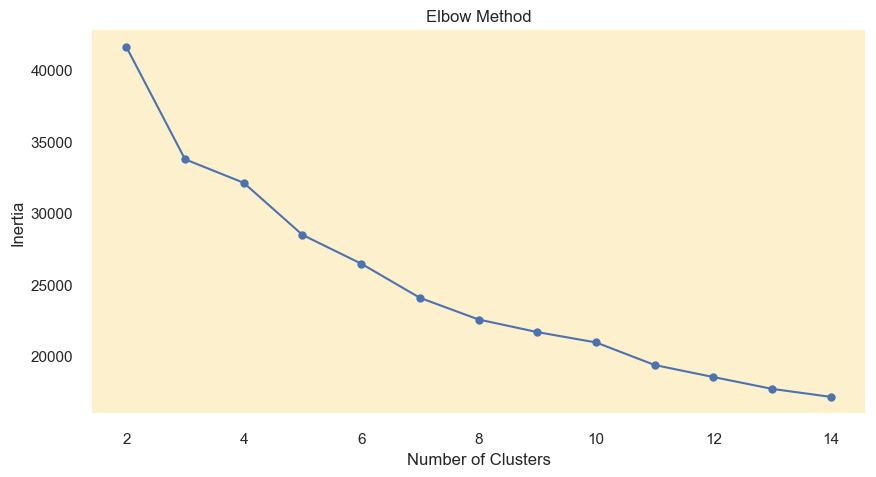

In [122]:
inertia = []

K = range(2,15)

for k in K:
    km = KMeans(n_clusters=k, n_init="auto", random_state=0)
    km.fit(customer_data_pca.values)
    inertia.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Optimal Number of Clusters
</h2>
The Elbow Method suggests that the optimal number of clusters is around k = 5, although a clear elbow point is not strongly visible, which is common in real-world datasets. The inertia decreases significantly up to k = 5, indicating that the optimal number of clusters likely lies between 3 and 7.

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Silhouette Method
</h2>

The Silhouette Method is used to evaluate clustering quality by measuring how well data points are grouped within their clusters and how well they are separated from other clusters. It calculates the silhouette coefficient for each data point to assess cluster cohesion and separation.

Silhouette Coefficient

For a data point i, the silhouette coefficient is computed as:

a(i): Average distance between point i and other points in the same cluster.

b(i): Average distance between point i and points in the nearest neighboring cluster.

The silhouette coefficient is given by:

s(i)= (b(i)−a(i)) / max(b(i),a(i))	​

The coefficient ranges from -1 to 1, where higher values indicate better cluster assignment.

Silhouette Score

The silhouette score is the average silhouette coefficient across all data points. 

<strong>A higher score indicates better-defined and well-separated clusters.</strong>

Advantages over the Elbow Method

Compared to the Elbow Method, silhouette analysis provides a more objective evaluation of clustering quality by considering both intra-cluster cohesion and inter-cluster separation. It also helps visualize cluster consistency and detect possible outliers, making it a more reliable metric for selecting the optimal number of clusters.

Methodology

Based on the Elbow Method, the number of clusters (k) will be tested within the range of 2 to 6. Silhouette scores will be computed for each value to identify the optimal k.

To further refine the selection, Silhouette plots will be generated to visualize cluster quality. The YellowBrick library will be used to support this comparative analysis.

In [123]:
# Function to perform silhouette analysis for a range of cluster values
def silhouette_analysis(X, start_k=3, stop_k=12, figsize=(14,18)):

    silhouette_scores = []

    # Compute silhouette scores
    for k in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=k, n_init="auto", random_state=0)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

    # Plot average silhouette scores
    plt.figure(figsize=(15,5))
    plt.plot(range(start_k, stop_k + 1), silhouette_scores, marker='o')
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Score for Different k")
    plt.grid()
    plt.show()

    
    # Create a range of cluster values to test
    k_range = range(start_k, stop_k + 1)

    # Create the main figure for all silhouette plots
    plt.figure(figsize=figsize)

    # Iterate through each cluster number
    for idx, k in enumerate(k_range):

        # Create subplot positions for each k
        plt.subplot(5, 2, idx + 1)

        # Initialize and fit the KMeans clustering model
        kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels = kmeans.fit_predict(X)

        # Calculate silhouette values for each sample
        sil_values = silhouette_samples(X, labels)

        # Compute the average silhouette score for the current k
        avg_score = silhouette_score(X, labels)

        # Initialize the starting vertical position for cluster plots
        y_lower = 10

        # Loop through each cluster to plot its silhouette distribution
        for i in range(k):

            # Extract silhouette scores for cluster i
            cluster_sil = sil_values[labels == i]

            # Sort the silhouette values for better visualization
            cluster_sil.sort()

            # Determine the size of the cluster
            size_cluster = cluster_sil.shape[0]
            y_upper = y_lower + size_cluster

            # Plot the silhouette values for the cluster
            plt.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                cluster_sil
            )

            # Update the vertical position for the next cluster
            y_lower = y_upper + 10

        # Draw a vertical line showing the average silhouette score
        plt.axvline(avg_score, linestyle="--")

        # Add plot titles and labels
        plt.title(f"k = {k} | Silhouette Score = {avg_score:.3f}")
        plt.xlabel("Silhouette Coefficient")
        plt.ylabel("Cluster Label")

    # Adjust layout to avoid overlapping plots
    plt.tight_layout()

    # Display the plots
    plt.show()

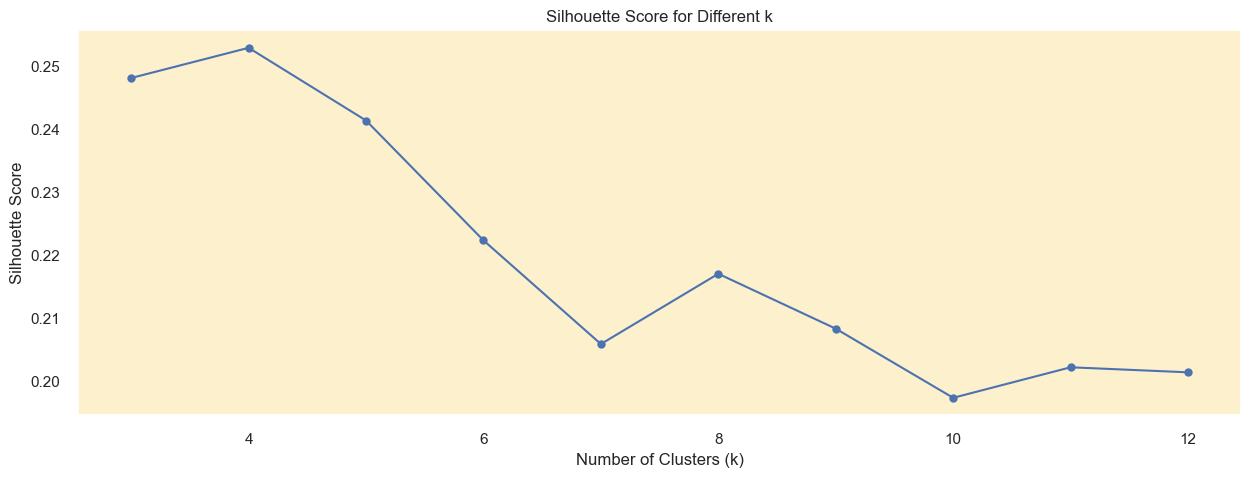

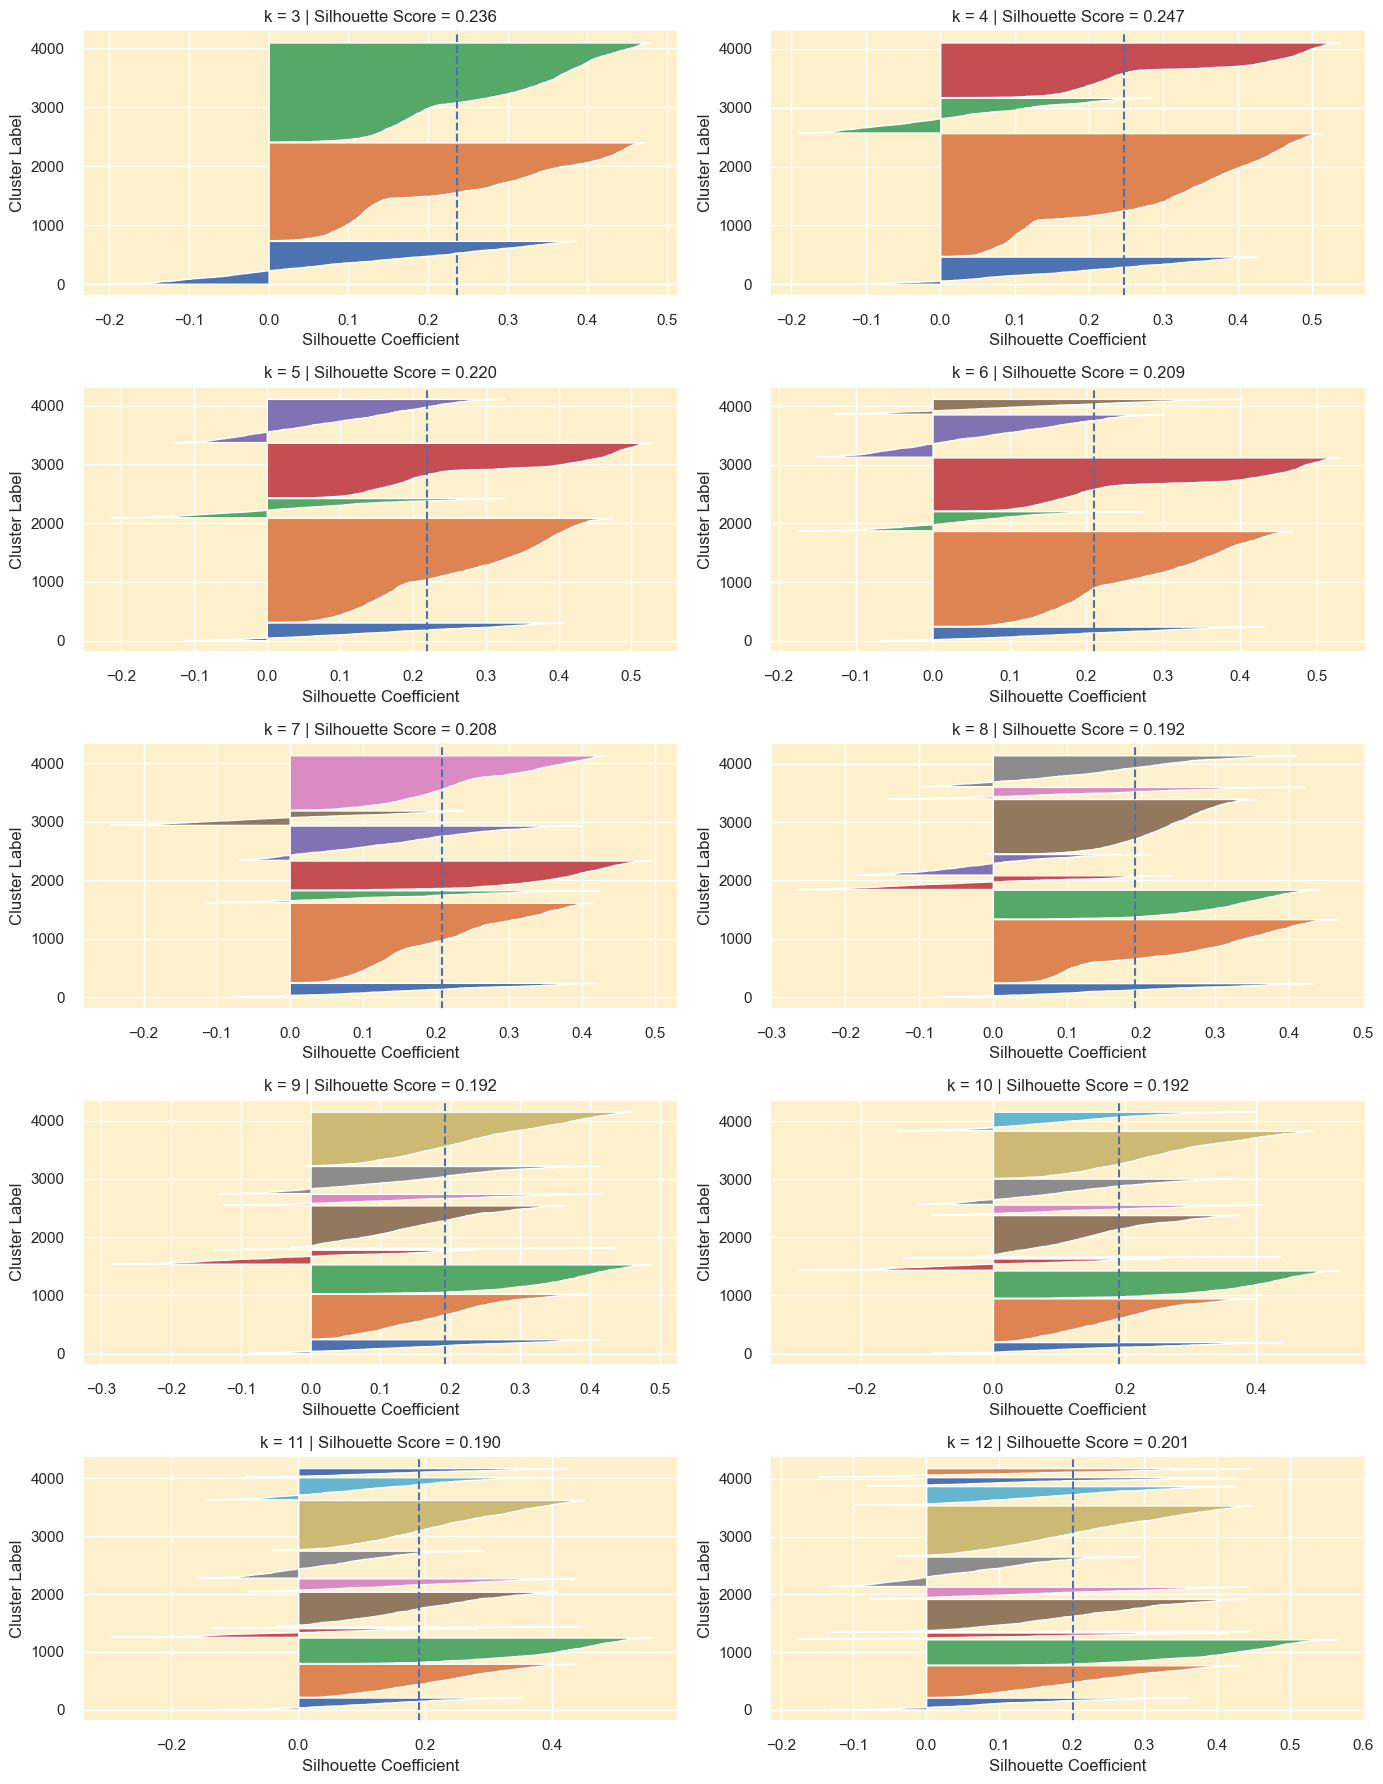

In [124]:
silhouette_analysis(customer_data_pca, 3, 12)

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Silhouette Method
</h2>

Selecting the Optimal Number of Clusters Using Silhouette Plots

To determine the optimal number of clusters, evaluate the silhouette plots using the following criteria:

Silhouette Score Width: Values closer to +1 indicate well-separated clusters, while values near -1 suggest poor separation. Higher average scores imply better clustering quality.

Cluster Size Balance: Prefer clusters with similar thickness and data point distribution, indicating balanced clustering.

Peak Average Score: Select the 𝑘 value that shows a clear peak in the average silhouette score.

Score Consistency: Avoid large fluctuations in silhouette widths across clusters.

Visual Compactness: Favor clusters with points closer to +1, showing compact and well-defined clusters.

Optimal Result:
After analyzing the silhouette plots, 

𝑘=3
 
is the most suitable choice as it provides well-balanced, distinct, and reliable clusters.

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Clustering Model - K-means
</h2>
Next, K-means clustering is applied to segment customers based on purchasing behavior and characteristics, using the previously determined optimal number of clusters. Since K-means may assign different labels in each run, cluster labels are standardized by swapping them according to sample frequency to ensure consistent labeling.

In [125]:
# applying k-mean clusturing using optimal k value from Silhouette Method

kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, max_iter=1000, random_state=0)
kmeans.fit(customer_data_pca)

#get the ferequency of each cluster
cluster_frequencies = Counter(kmeans.labels_)

#create a mappping from old labels based on frequency
label_mapping = {label: new_label for new_label, (label, _) in enumerate(cluster_frequencies.most_common())}

#reverse the mapping to assign labels
label_mapping = {v: k for k, v in {2:1, 1:0, 0:2}.items()}

#apply mapping to get new labels
new_labels = np.array([label_mapping[label] for label in kmeans.labels_]) 
# new_labels = np.array([label_mapping[label] for label in kmeans.labels_])

# Append the new cluster labels back to the original dataset
customer_data_cleaned['cluster'] = new_labels

# Append the new cluster labels to the PCA version of the dataset
customer_data_pca['cluster'] = new_labels


In [126]:
# Display the first few rows of the original dataframe
customer_data_cleaned.head()

,CustomerID,Days_since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,cluster
0,12346.0,325,2,0,0.0,0.0,1,0.0,1,10,1,1,0.5,0.0,0.0,0.0,2
1,12347.0,2,7,2458,4310.0,615.714286,103,2.016575,1,14,0,0,0.0,615.714286,341.070789,4.486071,0
2,12348.0,75,4,2332,1437.24,359.31,21,10.884615,3,19,0,0,0.0,359.31,203.875689,-100.884,1
3,12349.0,18,1,630,1457.55,1457.55,72,0.0,0,9,0,0,0.0,1457.55,0.0,0.0,2
4,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,0,0.0,294.4,0.0,0.0,2



<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Clustering Evaluation
</h2>

After determining the optimal number of clusters (k = 3) using the elbow and silhouette methods, the next step is to evaluate the clustering quality to ensure the clusters are coherent and well separated.

The evaluation includes:

3D Visualization of the Top Principal Components (PCs)

Cluster Distribution Visualization

Evaluation Metrics

Silhouette Score

Calinski–Harabasz Score

Davies–Bouldin Score

Note: The PCA-transformed dataset is used for evaluation because clustering was performed in this space, which captures the most important data patterns. Evaluating in this space provides a more accurate measure of cluster separation and cohesion, and also enables clearer 3D visualization using the top principal components.


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
3D Visualization of Top Principal Components
</h2>
In this step, the top three principal components (PCs)—which capture the most variance in the data—are selected to create a 3D visualization. This helps visually assess the separation and cohesion of the clusters.

In [127]:
# Setting up the color scheme for the clusters (RGB order)
colors = ["#ff0101", "#26ff00", "#020aff"]

#create separete dateframe
cluster0 = customer_data_pca[customer_data_pca["cluster"] == 0]
cluster1 = customer_data_pca[customer_data_pca["cluster"] == 1]
cluster2 = customer_data_pca[customer_data_pca["cluster"] == 2]

# Add clusters
fig = go.Figure()
for i, cluster in enumerate([cluster0, cluster1, cluster2]):
    fig.add_trace(go.Scatter3d(
        x=cluster['PC1'],
        y=cluster['PC2'],
        z=cluster['PC3'],
        mode='markers',
        marker=dict(color=colors[i], size=5, opacity=0.4),
        name=f'Cluster {i}'
    ))

# Layout
fig.update_layout(
    title='3D Visualization of Customer Clusters in PCA Space',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    width=900,
    height=800
)

fig.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Cluster Distribution Visualization
</h2>
Next using the bar plot to visualize the percentage of customers in each cluster, which helps in understanding if the clusters are balanced and significant:

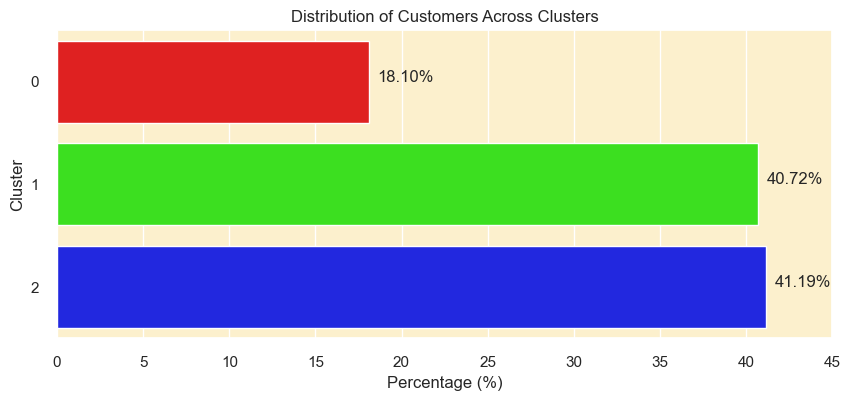

In [128]:
# Calculate cluster percentages
cluster_percentage = (
    customer_data_pca['cluster']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

cluster_percentage.columns = ['Cluster', 'Percentage']
cluster_percentage = cluster_percentage.sort_values('Cluster')

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    x='Percentage',
    y='Cluster',
    data=cluster_percentage,
    orient='h',
    palette=colors
)

# Add labels on bars
for i, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value + 0.5, i, f'{value:.2f}%')

# Labels and title
plt.title('Distribution of Customers Across Clusters')
plt.xlabel('Percentage (%)')
plt.xticks(np.arange(0, 50, 5))

plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Inference
</h2>

Customers are fairly distributed across clusters, with clusters 1 and 2 having about 41% each and cluster 0 around 18%. This indicates meaningful segmentation, where each cluster represents a significant and distinct group of customers, useful for analysis and decision-making.

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Evaluation Metrics
</h2>

<p>Silhouette Score: Measures how well clusters are separated between -1 to 1 (higher is better).</p>

<p>Calinski-Harabasz Score: Evaluates cluster dispersion (higher indicates better-defined clusters).</p>

<p>Davies-Bouldin Score: Measures similarity between clusters (lower is better).</p>

In [129]:
# Number of observations
num_observations = len(customer_data_pca)

# Features and cluster labels
X = customer_data_pca.drop(columns='cluster')
labels = customer_data_pca['cluster']

# Compute evaluation metrics
sil_score = silhouette_score(X, labels)
calinski_score = calinski_harabasz_score(X, labels)
davies_score = davies_bouldin_score(X, labels)

# Display results
results = [
    ["Number of Observations", num_observations],
    ["Silhouette Score", sil_score],
    ["Calinski-Harabasz Score", calinski_score],
    ["Davies-Bouldin Score", davies_score]
]

print(tabulate(results, headers=["Metric", "Value"], tablefmt="pretty"))

+-------------------------+---------------------+
|         Metric          |        Value        |
+-------------------------+---------------------+
| Number of Observations  |        4067         |
|    Silhouette Score     | 0.23622848017098863 |
| Calinski-Harabasz Score | 1257.1747766540627  |
|  Davies-Bouldin Score   |  1.368269537607467  |
+-------------------------+---------------------+


<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Clustering Quality Inference
</h2>

<p>The Silhouette Score (~0.236) indicates moderate cluster separation with some overlap.</p>
<p>The Calinski-Harabasz Score (1257.17) suggests well-defined and meaningful clusters.</p>
<p>The Davies-Bouldin Score (1.37) reflects reasonable separation, though not perfect. Overall, the clustering is of good quality, but there is still room for improvement in cluster separation.</p>

 <div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Cluster Analysis and Profiling
</h2>

<p>Analyze each cluster to understand the unique behaviors and preferences of different customer segments, and create profiles that highlight the key characteristics defining each group.

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Radar Chart Approach
</h2>

To visualize cluster profiles, radar charts will be used to compare centroid values across features. First, the centroid of each cluster is computed as the mean of all features within that cluster. These centroids are then plotted on radar charts to clearly show and compare the central tendencies of each cluster.

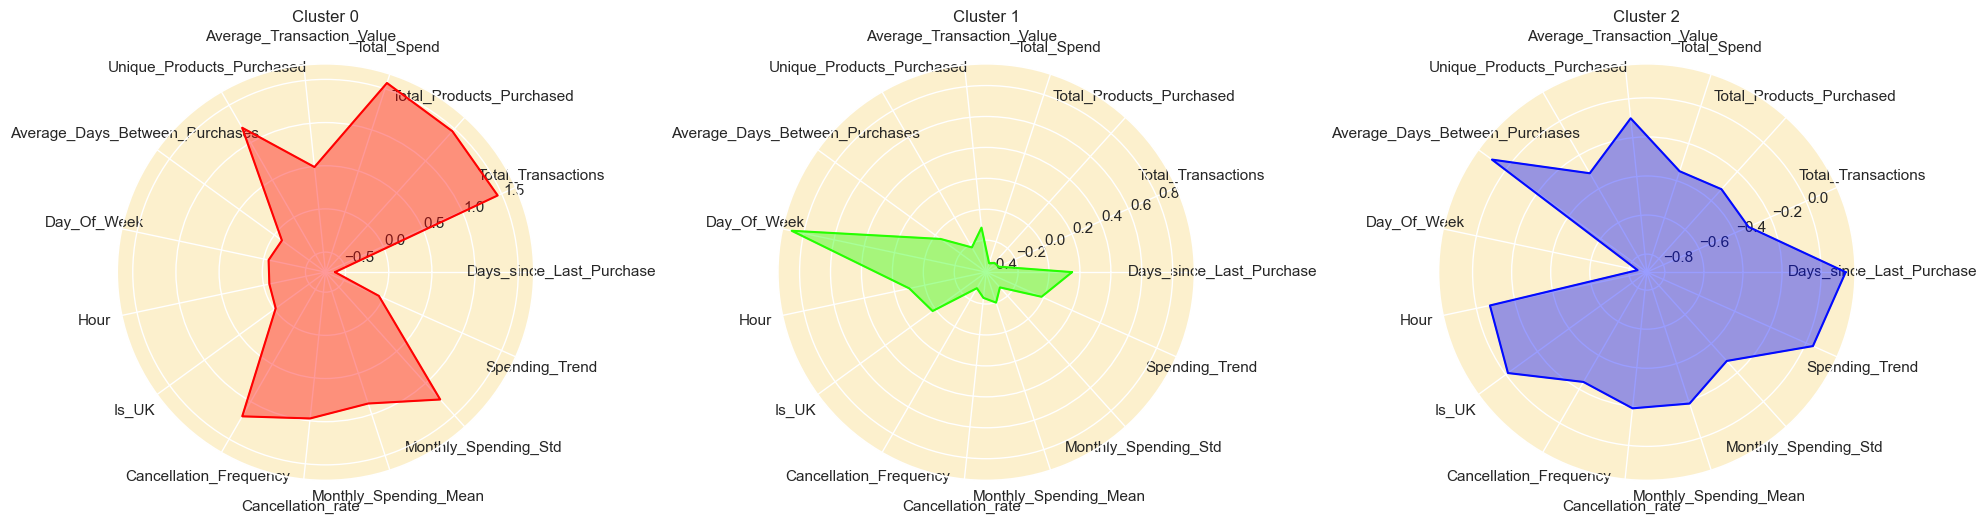

In [130]:
# Set index
df_customer = customer_data_cleaned.set_index('CustomerID')

# Standardize features (excluding cluster)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_customer.drop(columns='cluster'))

# Create standardized dataframe
df_scaled = pd.DataFrame(X_scaled, columns=df_customer.columns[:-1], index=df_customer.index)
df_scaled['cluster'] = df_customer['cluster']

# Compute centroids
centroids = df_scaled.groupby('cluster').mean()

# Radar chart setup
labels = centroids.columns
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 8), subplot_kw=dict(polar=True))

for i, ax in enumerate(axes):
    values = centroids.loc[i].tolist()
    values += values[:1]
    
    ax.plot(angles, values, color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.4)
    
    ax.set_title(f'Cluster {i}')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Customer Profiles
</h2>
<p>Cluster 0 (Red): Low-spending customers with fewer transactions and products purchased. They tend to shop on weekends, show stable but low spending patterns, and have very low cancellation rates.</p>
<p>Cluster 1 (Yellow): Customers who purchase less frequently but spend more per transaction. Their spending is increasing over time, they prefer shopping later in the day, and show moderate cancellation behavior.</p>
<p>Cluster 2 (Blue): High-value and frequent shoppers who buy many products. They have high cancellation rates and more fluctuating spending patterns, often shopping earlier in the day.</p>

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Histogram Chart Approach
</h2>

To validate the cluster profiles, histograms can be plotted for each feature by cluster. This helps visualize how feature values are distributed within each group, allowing us to confirm or refine the insights from the radar charts.

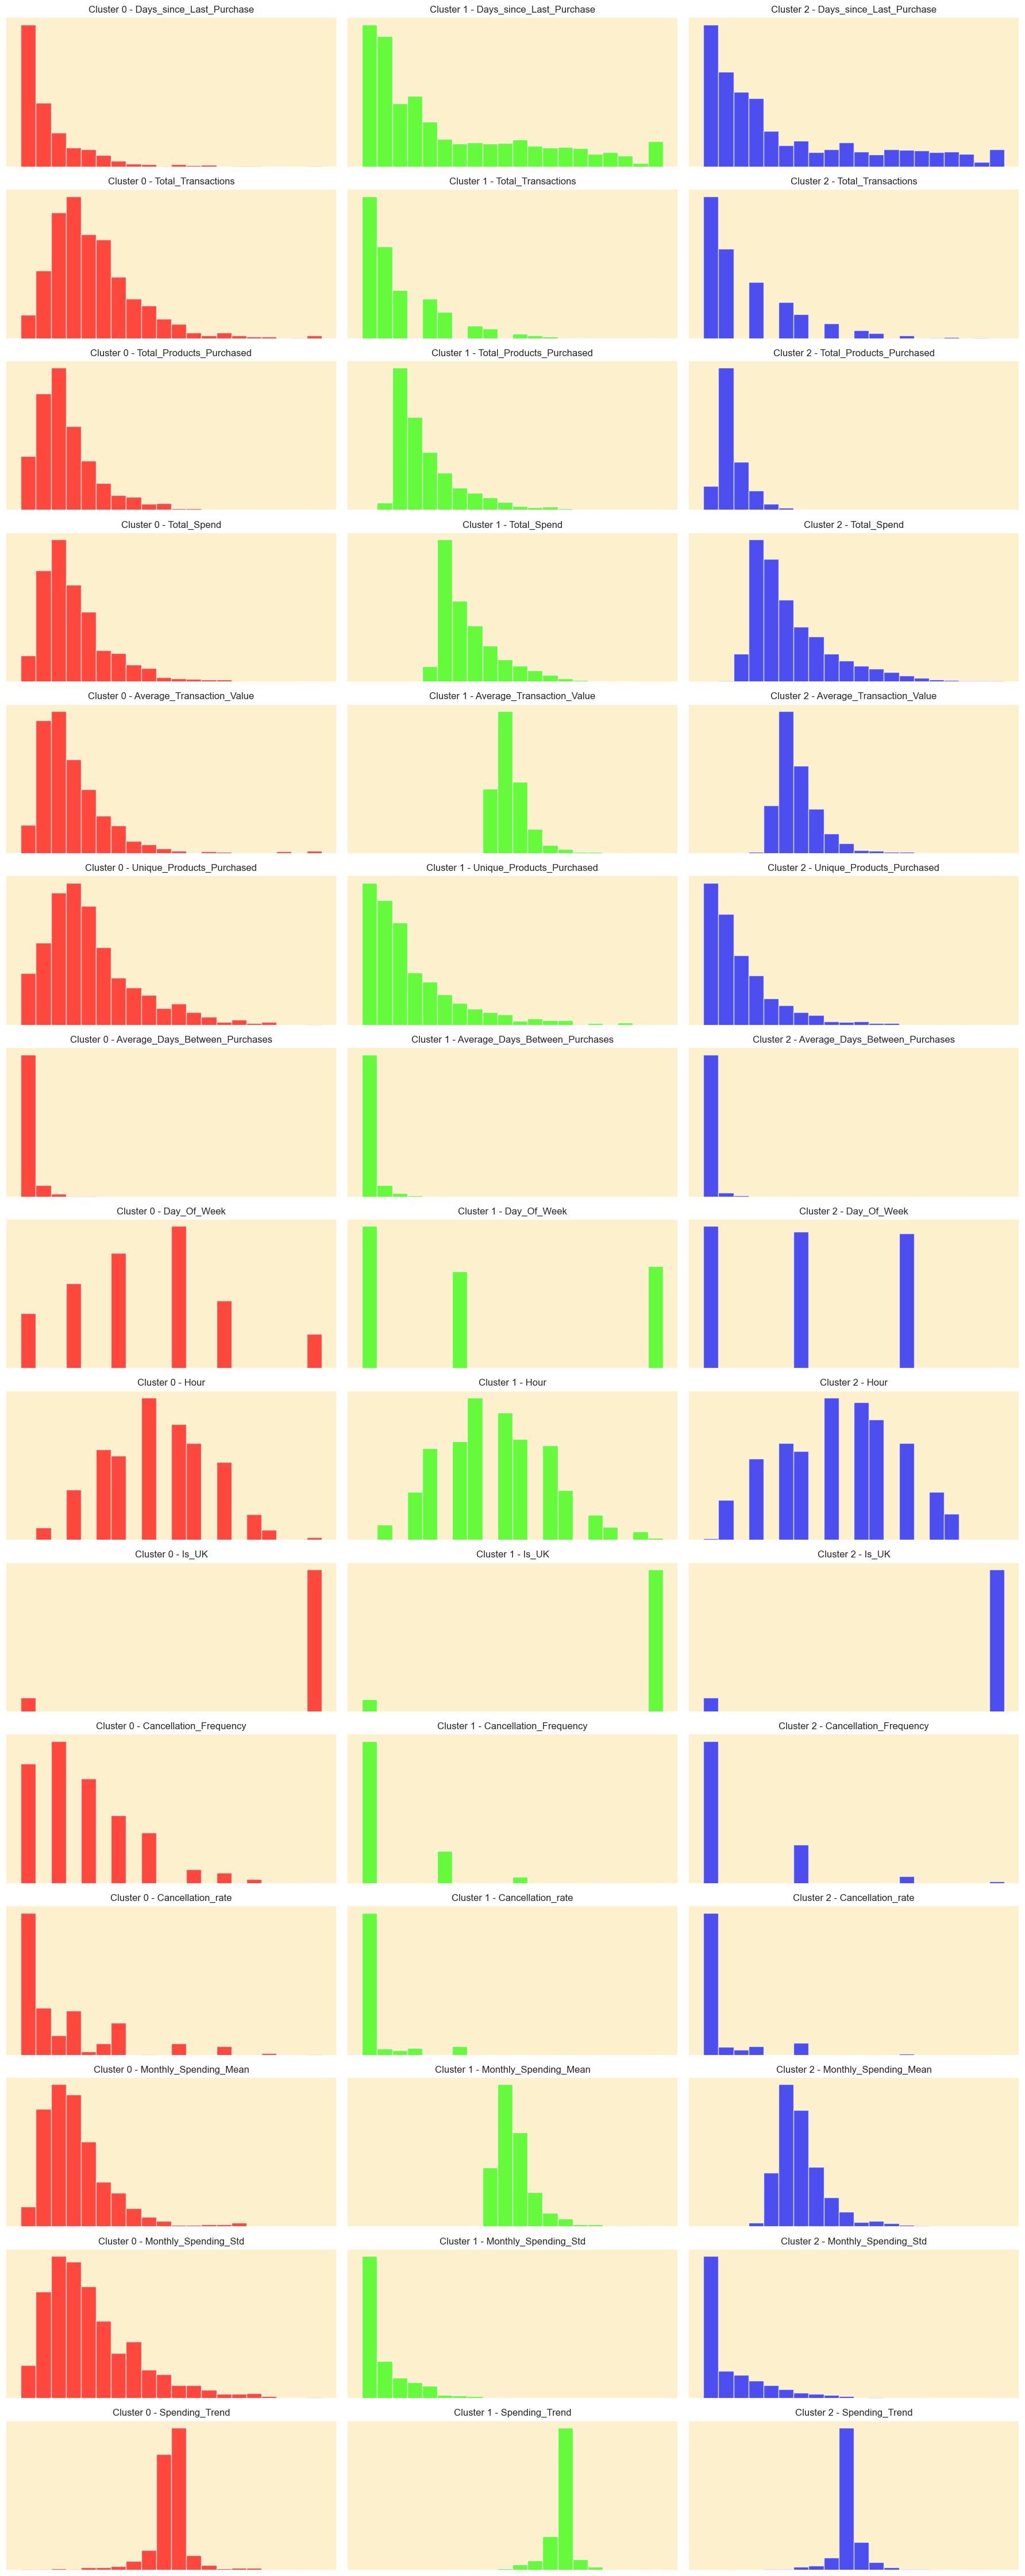

In [131]:
# Features and clusters
features = customer_data_cleaned.columns[1:-1]
clusters = sorted(customer_data_cleaned['cluster'].unique())

# Create subplots
fig, axes = plt.subplots(len(features), len(clusters), figsize=(18, 3 * len(features)))

# Plot histograms
for i, feature in enumerate(features):
    for j, cluster in enumerate(clusters):
        subset = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster][feature]
        
        ax = axes[i, j]
        ax.hist(subset, bins=20, color=colors[j], alpha=0.7, edgecolor='white')
        ax.set_title(f'Cluster {cluster} - {feature}', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #020617, #0f172a);
    padding: 3%;
    margin: 2% auto;
    border-radius: 16px;
    color: #e5e7eb;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 6px 18px rgba(0,0,0,0.35);
    box-sizing: border-box;
    max-width: 1500px;
    width: 95%;
">

<h2 style="
    color:#38bdf8;
    margin-bottom:18px;
    text-align:left;
">
Recommendation System
</h2>

In the final stage, a recommendation system is developed to improve the shopping experience by suggesting products based on each customer’s cluster behavior. After excluding 5% of outliers into a separate dataset, the focus is on the main 95% of customers. For each cluster, the top-selling products are identified and used to recommend the top three items that a customer hasn’t purchased yet. This approach enables personalized recommendations and targeted marketing, helping increase engagement and sales. For outliers, a simple strategy is to recommend random products as a starting point.

In [132]:
# Step 1: Extract the CustomerIDs of the outliers and remove their transactions from the main dataframe
df = df.reset_index() 
outlier_customer_ids = outliers_data['CustomerID'].astype('float').unique()
df_filtered = df[~df['CustomerID'].isin(outlier_customer_ids)]

# # Step 2: Ensure consistent data type for CustomerID across both dataframes before merging
# customer_data_cleaned['CustomerID'] = customer_data_cleaned['CustomerID'].astype('float')
df_filtered['CustomerID'] = df_filtered['CustomerID'].astype(str).str.strip()
customer_data_cleaned['CustomerID'] = customer_data_cleaned['CustomerID'].astype(str).str.strip()


In [133]:
merged_data = df_filtered.drop(columns=['cluster'], errors='ignore') \
    .merge(customer_data_cleaned[['CustomerID', 'cluster']], on='CustomerID', how='inner')

merged_data.head()


,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_Status,InvoiceDay,Total_Spend,Day_Of_Week,Hour,Year,Month,cluster
0,9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,Completed,2010-12-01,54.08,2,8,2010,12,0
1,10,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,2010-12-01 08:34:00,2.10,13047.0,United Kingdom,Completed,2010-12-01,12.60,2,8,2010,12,0
2,11,536367,22748,POPPY'S PLAYHOUSE KITCHEN,6,2010-12-01 08:34:00,2.10,13047.0,United Kingdom,Completed,2010-12-01,12.60,2,8,2010,12,0
3,12,536367,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,8,2010-12-01 08:34:00,3.75,13047.0,United Kingdom,Completed,2010-12-01,30.00,2,8,2010,12,0
4,13,536367,22310,IVORY KNITTED MUG COSY,6,2010-12-01 08:34:00,1.65,13047.0,United Kingdom,Completed,2010-12-01,9.90,2,8,2010,12,0


In [134]:
# Step 4: Identify the top 10 best-selling products in each cluster based on the total quantity sold
best_selling_products = merged_data.groupby(['cluster', 'StockCode', 'Description'])['Quantity'].sum().reset_index()
best_selling_products = best_selling_products.sort_values(by=['cluster', 'Quantity'], ascending=[True, False])
top_products_per_cluster = best_selling_products.groupby('cluster').head(10)

# Step 5: Create a record of products purchased by each customer in each cluster
customer_purchases = merged_data.groupby(['CustomerID', 'cluster', 'StockCode'])['Quantity'].sum().reset_index()

# Step 6: Generate recommendations for each customer in each cluster
recommendations = []
for cluster in top_products_per_cluster['cluster'].unique():
    top_products = top_products_per_cluster[top_products_per_cluster['cluster'] == cluster]
    customers_in_cluster = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster]['CustomerID']
    
    for customer in customers_in_cluster:
        # Identify products already purchased by the customer
        customer_purchased_products = customer_purchases[(customer_purchases['CustomerID'] == customer) & 
                                                         (customer_purchases['cluster'] == cluster)]['StockCode'].tolist()
        
        # Find top 3 products in the best-selling list that the customer hasn't purchased yet
        top_products_not_purchased = top_products[~top_products['StockCode'].isin(customer_purchased_products)]
        top_3_products_not_purchased = top_products_not_purchased.head(3)
        
        # Append the recommendations to the list
        recommendations.append([customer, cluster] + top_3_products_not_purchased[['StockCode', 'Description']].values.flatten().tolist())

# Step 7: Create a dataframe from the recommendations list and merge it with the original customer data
recommendations_df = pd.DataFrame(recommendations, columns=['CustomerID', 'cluster', 'Rec1_StockCode', 'Rec1_Description', \
                                                 'Rec2_StockCode', 'Rec2_Description', 'Rec3_StockCode', 'Rec3_Description'])
customer_data_with_recommendations = customer_data_cleaned.merge(recommendations_df, on=['CustomerID', 'cluster'], how='right')

In [135]:
customer_data_with_recommendations.set_index('CustomerID').iloc[:, -6:].sample(10, random_state=0)

,Rec1_StockCode,Rec1_Description,Rec2_StockCode,Rec2_Description,Rec3_StockCode,Rec3_Description
CustomerID,,,,,,
13243.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT,15036,ASSORTED COLOURS SILK FAN
13232.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT,15036,ASSORTED COLOURS SILK FAN
14997.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,84879,ASSORTED COLOUR BIRD ORNAMENT,17003,BROCADE RING PURSE
14948.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,84879,ASSORTED COLOUR BIRD ORNAMENT,17003,BROCADE RING PURSE
12596.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,84879,ASSORTED COLOUR BIRD ORNAMENT,17003,BROCADE RING PURSE
16686.0,22616,PACK OF 12 LONDON TISSUES,85099B,JUMBO BAG RED RETROSPOT,84879,ASSORTED COLOUR BIRD ORNAMENT
17101.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,84879,ASSORTED COLOUR BIRD ORNAMENT,17003,BROCADE RING PURSE
14954.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT,15036,ASSORTED COLOURS SILK FAN
18123.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,84879,ASSORTED COLOUR BIRD ORNAMENT,17003,BROCADE RING PURSE
